## Task 1 — Data Loading, Merging & Deep Exploration

This task focuses on loading the Superstore Sales dataset, preprocessing it by parsing date columns and extracting time-based features, and preparing for initial exploratory analysis.

In [1]:
import pandas as pd

# Load the Superstore Sales CSV using Pandas
df = pd.read_csv('/content/train.csv')

# Parse the Order Date and Ship Date columns as proper datetime objects
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

# Extract time features from 'Order Date'
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
df['Order Day of Week'] = df['Order Date'].dt.dayofweek # Monday=0, Sunday=6
df['Order Quarter'] = df['Order Date'].dt.quarter

# Define seasons (Northern Hemisphere)
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df['Order Season'] = df['Order Month'].apply(get_season)

# Display the first 5 rows and info to verify changes
display(df.head())
df.info()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Order Year,Order Month,Order Week,Order Day of Week,Order Quarter,Order Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,2,4,Fall
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,2,4,Fall
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,0,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,1,4,Fall
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,1,4,Fall


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Row ID             9800 non-null   int64         
 1   Order ID           9800 non-null   object        
 2   Order Date         9800 non-null   datetime64[ns]
 3   Ship Date          9800 non-null   datetime64[ns]
 4   Ship Mode          9800 non-null   object        
 5   Customer ID        9800 non-null   object        
 6   Customer Name      9800 non-null   object        
 7   Segment            9800 non-null   object        
 8   Country            9800 non-null   object        
 9   City               9800 non-null   object        
 10  State              9800 non-null   object        
 11  Postal Code        9789 non-null   float64       
 12  Region             9800 non-null   object        
 13  Product ID         9800 non-null   object        
 14  Category

In [2]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nNumber of duplicate rows:")
print(df.duplicated().sum())

# Check for data types (already shown by df.info() but good for explicit check)
print("\nData types:")
print(df.dtypes)


Missing values per column:
Row ID                0
Order ID              0
Order Date            0
Ship Date             0
Ship Mode             0
Customer ID           0
Customer Name         0
Segment               0
Country               0
City                  0
State                 0
Postal Code          11
Region                0
Product ID            0
Category              0
Sub-Category          0
Product Name          0
Sales                 0
Order Year            0
Order Month           0
Order Week            0
Order Day of Week     0
Order Quarter         0
Order Season          0
dtype: int64

Number of duplicate rows:
0

Data types:
Row ID                        int64
Order ID                     object
Order Date           datetime64[ns]
Ship Date            datetime64[ns]
Ship Mode                    object
Customer ID                  object
Customer Name                object
Segment                      object
Country                      object
City             

In [3]:
# Handle missing values in 'Postal Code' by dropping rows
df.dropna(subset=['Postal Code'], inplace=True)
print(f"\nDataFrame shape after dropping missing postal codes: {df.shape}")

# Aggregate daily sales into weekly totals
weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
weekly_sales.rename(columns={'Order Date': 'Week', 'Sales': 'Weekly Sales'}, inplace=True)

# Aggregate daily sales into monthly totals (using 'ME' to avoid FutureWarning)
monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
monthly_sales.rename(columns={'Order Date': 'Month', 'Sales': 'Monthly Sales'}, inplace=True)

print("\nWeekly Sales Aggregation (first 5 rows):")
display(weekly_sales.head())
print("\nMonthly Sales Aggregation (first 5 rows):")
display(monthly_sales.head())


# Which product category generates the highest total revenue?
category_revenue = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)
print("\nProduct Category by Total Revenue:")
display(category_revenue)


DataFrame shape after dropping missing postal codes: (9789, 24)

Weekly Sales Aggregation (first 5 rows):


,Week,Weekly Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914



Monthly Sales Aggregation (first 5 rows):


,Month,Monthly Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303



Product Category by Total Revenue:


,Sales
Category,
Technology,825856.1130
Furniture,723538.4757
Office Supplies,703212.8240


In [4]:
# Which region has the most consistent sales growth over 4 years?
# Calculate yearly sales for each region
yearly_sales_region = df.groupby(['Order Year', 'Region'])['Sales'].sum().unstack()

# Calculate year-over-year growth percentage
year_over_year_growth = yearly_sales_region.pct_change().dropna()

# Analyze consistency (e.g., standard deviation of growth rates)
# Lower standard deviation indicates more consistent growth
growth_consistency = year_over_year_growth.std().sort_values()

print("\nYearly Sales by Region (first 5 rows of growth data):")
display(yearly_sales_region)
print("\nYear-over-Year Sales Growth by Region (first 5 rows):")
display(year_over_year_growth)
print("\nSales Growth Consistency (Standard Deviation of Growth Rates by Region):")
display(growth_consistency)


Yearly Sales by Region (first 5 rows of growth data):


Region,Central,East,South,West
Order Year,,,,
2015,102920.5206,127652.819,103374.9055,145907.9630
2016,102425.1724,148105.083,70076.0825,133709.5675
2017,145673.8800,175544.478,93535.9035,182471.2285
2018,141627.3402,209286.976,122164.5675,248130.9255



Year-over-Year Sales Growth by Region (first 5 rows):


Region,Central,East,South,West
Order Year,,,,
2016,-0.004813,0.160218,-0.322117,-0.083603
2017,0.422247,0.185270,0.334776,0.364683
2018,-0.027778,0.192216,0.306071,0.359836



Sales Growth Consistency (Standard Deviation of Growth Rates by Region):


,0
Region,
East,0.016831
Central,0.253453
West,0.257431
South,0.371249


In [5]:
# What is the average time between Order Date and Ship Date — and does it vary by region?

# Calculate the difference between Ship Date and Order Date
df['Shipping Time'] = (df['Ship Date'] - df['Order Date']).dt.days

# Calculate the overall average shipping time
overall_avg_shipping_time = df['Shipping Time'].mean()

# Calculate average shipping time by region
shipping_time_by_region = df.groupby('Region')['Shipping Time'].mean().sort_values(ascending=False)

print(f"\nOverall Average Shipping Time: {overall_avg_shipping_time:.2f} days")
print("\nAverage Shipping Time by Region:")
display(shipping_time_by_region)


Overall Average Shipping Time: 3.96 days

Average Shipping Time by Region:


,Shipping Time
Region,
Central,4.065876
South,3.961202
West,3.930255
East,3.910238


In [6]:
# Are there months that consistently spike across all years (seasonality)?

# Aggregate monthly sales by year and month
monthly_sales_by_year = df.groupby(['Order Year', 'Order Month'])['Sales'].sum().unstack()

# Calculate the average sales for each month across all years
average_monthly_sales = monthly_sales_by_year.mean().sort_values(ascending=False)

print("\nMonthly Sales by Year (first 5 rows):")
display(monthly_sales_by_year.head())
print("\nAverage Monthly Sales Across All Years:")
display(average_monthly_sales)


Monthly Sales by Year (first 5 rows):


Order Month,1,2,3,4,5,6,7,8,9,10,11,12
Order Year,,,,,,,,,,,,
2015,14205.7070,4519.8920,55205.7970,27906.8550,23644.3030,34322.9356,33781.543,27117.5365,81623.5268,31453.3930,77907.6607,68167.0585
2016,18066.9576,11951.4110,32339.3184,34154.4685,29959.5305,23599.3740,28608.259,36818.3422,63133.6060,31011.7375,70129.2995,74543.6012
2017,16870.1810,22978.8150,51165.0590,37385.0170,56656.9080,39724.4860,38320.783,30542.2003,69193.3909,59583.0330,79066.4958,95739.1210
2018,42839.2940,19920.9974,58863.4128,35541.9101,43825.9822,48190.7277,44825.104,62837.8480,86152.8880,77448.1312,117938.1550,82825.3588



Average Monthly Sales Across All Years:


,0
Order Month,
11,86260.402750
12,80318.784875
9,75025.852925
10,49874.073675
3,49393.396800
8,39328.981750
5,38521.680925
6,36459.380825
7,36383.922250


## Task 2 — Time Series Analysis & Decomposition

This task focuses on analyzing the monthly sales trend, decomposing the time series into trend, seasonal, and residual components, and checking for stationarity.

### 2.1 Plot Overall Monthly Sales Trend

Let's visualize the `monthly_sales` data to understand the overall sales trend over time.

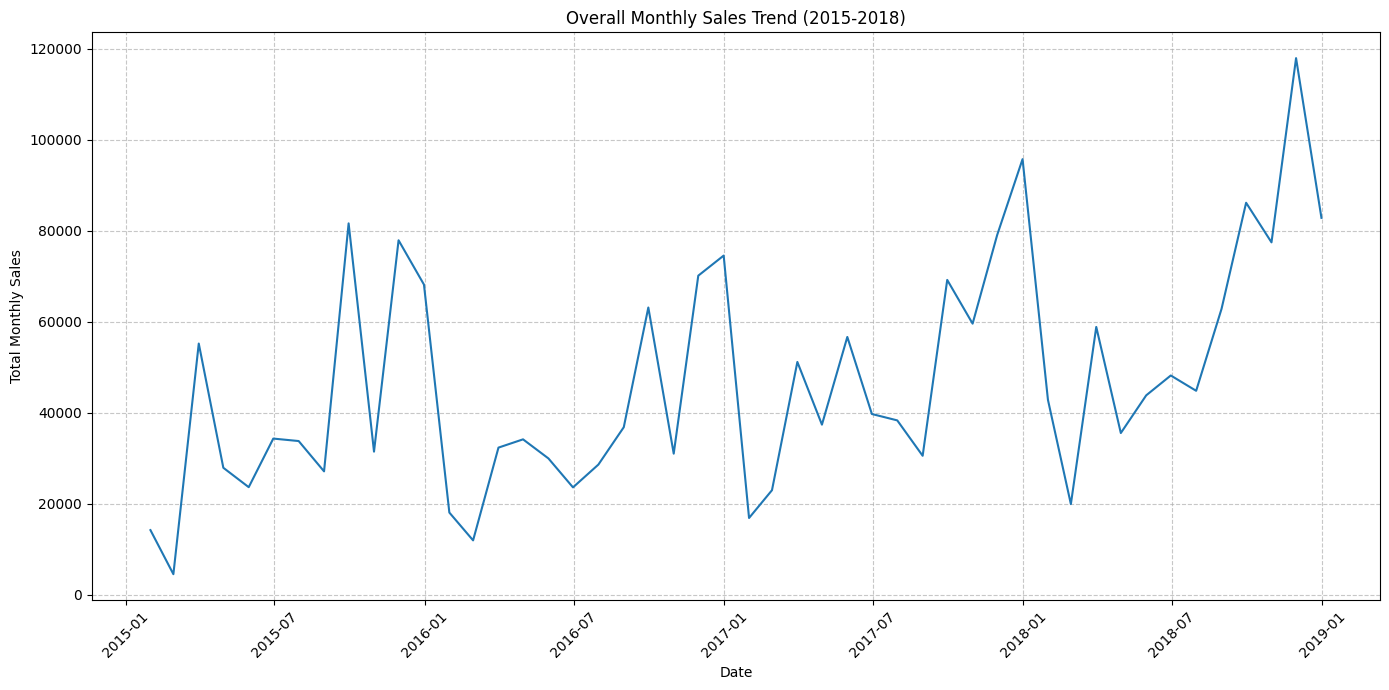

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(x='Month', y='Monthly Sales', data=monthly_sales)
plt.title('Overall Monthly Sales Trend (2015-2018)')
plt.xlabel('Date')
plt.ylabel('Total Monthly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 2.2 Time Series Decomposition

We will now use `statsmodels` to decompose the `monthly_sales` time series into its trend, seasonal, and residual components. This will help us understand the underlying patterns more clearly.

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Set the 'Month' column as the index for time series decomposition
monthly_sales_ts = monthly_sales.set_index('Month')

# Decompose the time series
# 'model="additive"' is often appropriate when the magnitude of the seasonal fluctuations
# does not vary with the level of the time series. If fluctuations increase with the series level,
# a multiplicative model might be more suitable.
# 'period' is set to 12 as we are using monthly data and assuming yearly seasonality.
decomposition = seasonal_decompose(monthly_sales_ts['Monthly Sales'], model='additive', period=12)

print("Time series decomposition completed.")

Time series decomposition completed.


### 2.3 Plotting Decomposed Components

Let's plot the observed, trend, seasonal, and residual components to visually inspect the decomposition.

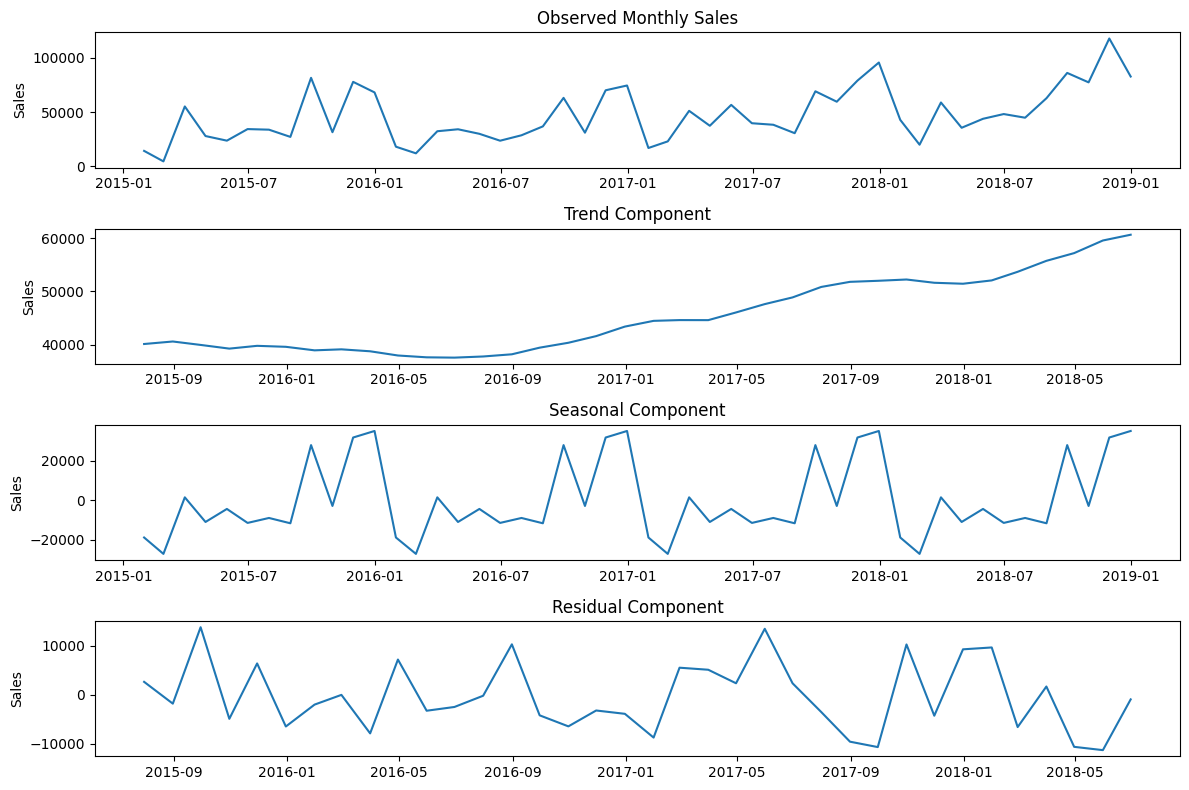

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

plt.subplot(4, 1, 1)
plt.plot(decomposition.observed)
plt.title('Observed Monthly Sales')
plt.ylabel('Sales')

plt.subplot(4, 1, 2)
plt.plot(decomposition.trend)
plt.title('Trend Component')
plt.ylabel('Sales')

plt.subplot(4, 1, 3)
plt.plot(decomposition.seasonal)
plt.title('Seasonal Component')
plt.ylabel('Sales')

plt.subplot(4, 1, 4)
plt.plot(decomposition.resid)
plt.title('Residual Component')
plt.ylabel('Sales')

plt.tight_layout()
plt.show()

### 2.4 Check for Stationarity (Augmented Dickey-Fuller Test)

**Stationarity** is a key concept in time series analysis. A stationary time series is one whose statistical properties (mean, variance, autocorrelation, etc.) do not change over time. Many time series models (like ARIMA) assume that the series is stationary.

The **Augmented Dickey-Fuller (ADF) Test** is a statistical test used to determine if a time series is stationary. The null hypothesis of the ADF test is that the time series is non-stationary (it has a unit root). If the p-value is less than a chosen significance level (e.g., 0.05), we can reject the null hypothesis and conclude that the time series is stationary.

In [10]:
from statsmodels.tsa.stattools import adfuller

def check_stationarity(timeseries):
    # Perform Augmented Dickey-Fuller test
    adf_test = adfuller(timeseries, autolag='AIC')

    # Extract results
    adf_statistic = adf_test[0]
    p_value = adf_test[1]
    critical_values = adf_test[4]

    print(f"ADF Statistic: {adf_statistic:.2f}")
    print(f"P-value: {p_value:.3f}")
    print("Critical Values:")
    for key, value in critical_values.items():
        print(f"  {key}: {value:.2f}")

    if p_value < 0.05: # Using a 5% significance level
        print("\nConclusion: The time series is likely stationary (reject H0).")
    else:
        print("\nConclusion: The time series is likely non-stationary (fail to reject H0).")

print("Checking stationarity for Original Monthly Sales:")
check_stationarity(monthly_sales_ts['Monthly Sales'].dropna())

Checking stationarity for Original Monthly Sales:
ADF Statistic: -4.42
P-value: 0.000
Critical Values:
  1%: -3.58
  5%: -2.93
  10%: -2.60

Conclusion: The time series is likely stationary (reject H0).


### Interpretation of Stationarity and ADF Test Results

**What is Stationarity?**
In simple terms, a stationary time series is one whose statistical properties (like its mean, variance, and autocorrelation) don't change over time. Imagine a wobbly line graph: if it's stationary, its wiggles and average height tend to stay consistent, no matter which part of the graph you look at. If it's non-stationary, it might have a clear upward or downward trend, or its fluctuations might get bigger or smaller over time.

**Why is Stationarity Important?**
Many time series models, especially traditional ones like ARIMA, assume that the data they're working with is stationary. If you try to apply these models to non-stationary data, your forecasts might be unreliable or simply incorrect. It's like trying to use a tool designed for a flat surface on a steep hill – it won't work as intended.

**What Our Test Result Tells Us:**
Our Augmented Dickey-Fuller (ADF) test yielded a P-value of **0.000**. This value is much smaller than the common significance level of 0.05 (or 5%).

*   The **null hypothesis** of the ADF test is that the time series *is non-stationary* (it has a unit root, meaning it has a trend or unpredictable changes).
*   Since our P-value (0.000) is less than 0.05, we **reject the null hypothesis**.

This means we have strong evidence to conclude that our `monthly_sales` time series **is stationary**. This is a great outcome because it simplifies future modeling steps; we don't need to perform techniques like differencing to make the series stationary.

Because the original series is already stationary, we **do not need to apply differencing or re-test for stationarity**.

## Task 3 — Sales Forecasting using 3 Different Models

This task focuses on building, training, and comparing three fundamentally different forecasting approaches to predict future sales.

### 3.2 Forecasting with SARIMA (Seasonal AutoRegressive Integrated Moving Average) Model

Given the clear seasonality identified in our time series decomposition, the Seasonal ARIMA (SARIMA) model is a more appropriate choice than a simple ARIMA model. SARIMA extends ARIMA by incorporating seasonal terms.

SARIMA models are denoted as ARIMA(p,d,q)(P,D,Q)m, where:
*   **(p, d, q)** are the non-seasonal components (AR, I, MA orders).
*   **(P, D, Q)** are the seasonal components (Seasonal AR, Seasonal I, Seasonal MA orders).
*   **m** is the number of time steps for a single seasonal period (which is 12 for monthly data with yearly seasonality).

**Parameter Choice Explanation:**
*   **Non-seasonal (p, d, q):**
    *   **d = 0:** We determined the time series is stationary, so no non-seasonal differencing is needed.
    *   **p = 1, q = 1:** As a starting point, we'll use simple AR(1) and MA(1) terms, similar to the initial ARIMA model.
*   **Seasonal (P, D, Q, m):**
    *   **m = 12:** Our data is monthly, and we observe yearly seasonality.
    *   **D = 0:** The series was found to be stationary, suggesting no seasonal differencing is strictly necessary, though sometimes a small D can improve seasonal fit. We'll start with 0.
    *   **P = 1, Q = 1:** We'll use simple seasonal AR(1) and MA(1) terms to capture the yearly seasonal patterns.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency ME will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


SARIMA model fitting complete.
                                     SARIMAX Results                                      
Dep. Variable:                      Monthly Sales   No. Observations:                   36
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 12)   Log Likelihood                -406.226
Date:                            Thu, 09 Jul 2026   AIC                            822.452
Time:                                    04:14:31   BIC                            830.370
Sample:                                01-31-2015   HQIC                           825.216
                                     - 12-31-2017                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9559      0.156      6.130      0.000       0.650       1.262
ma.L

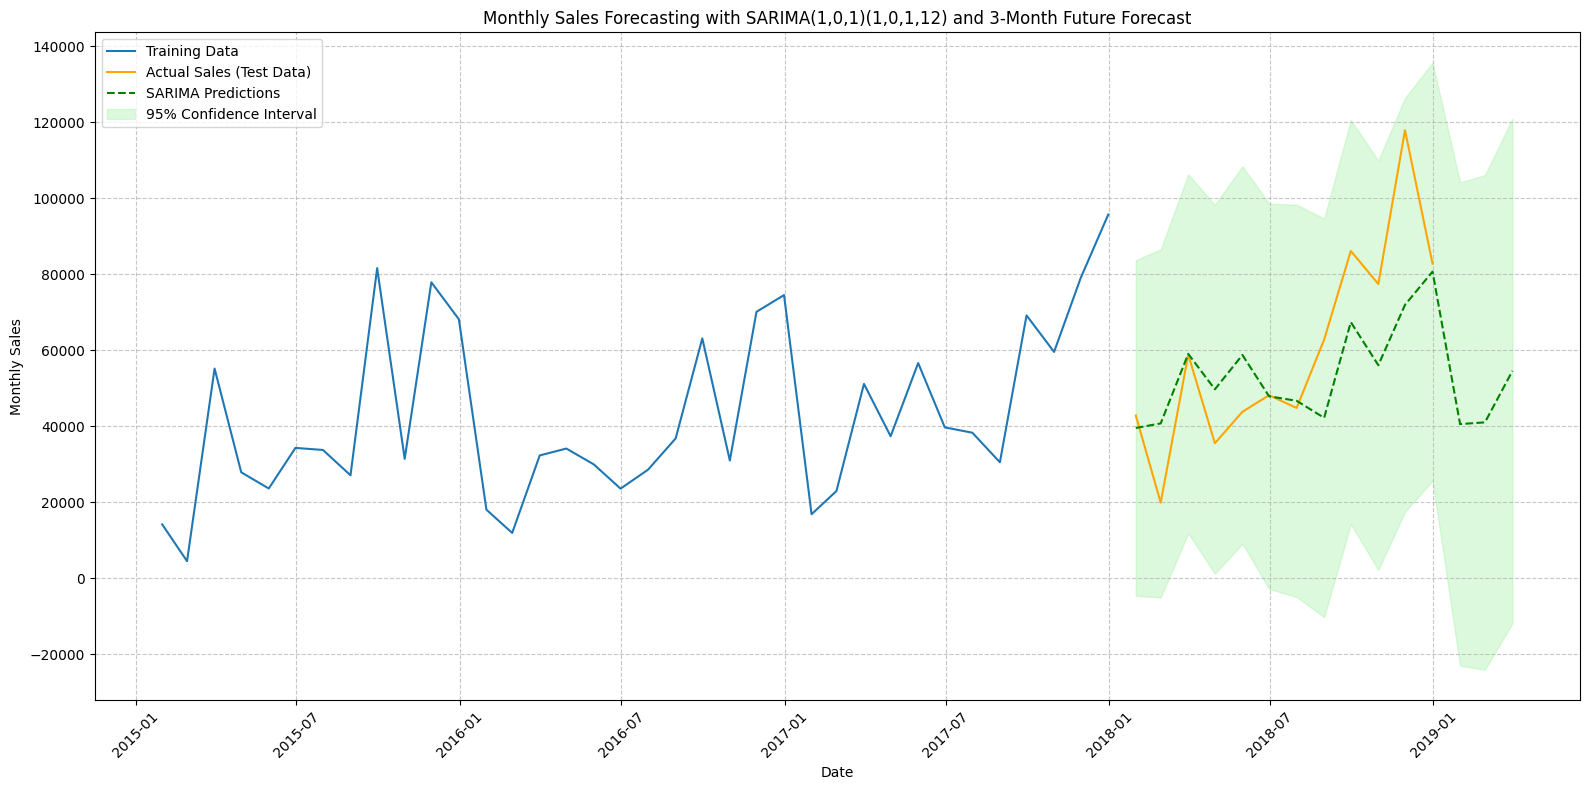

In [11]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Ensure monthly_sales_ts, train_data, and test_data are prepared
# This section is critical to run if the ARIMA cell (where they were first defined) hasn't been executed or if the kernel was reset.
monthly_sales_ts = monthly_sales.set_index('Month')
train_size = len(monthly_sales_ts) - 12
train_data, test_data = monthly_sales_ts[0:train_size], monthly_sales_ts[train_size:]

# Fit SARIMA model
# (p,d,q) = (1,0,1) for non-seasonal, (P,D,Q,m) = (1,0,1,12) for seasonal
sarima_model = SARIMAX(train_data['Monthly Sales'], order=(1,0,1), seasonal_order=(1,0,1,12))
sarima_model_fit = sarima_model.fit(disp=False)

print("SARIMA model fitting complete.")
print(sarima_model_fit.summary())

# Generate a 3-month future forecast
# Define the number of steps to forecast beyond the test set
forecast_steps = 3

# Get the forecast for the test period + 3 future months
# The start of the forecast should be the first index of the test data
# The end of the forecast should be the last index of the test data + forecast_steps - 1

forecast_start_index = len(train_data)
forecast_end_index = len(monthly_sales_ts) + forecast_steps - 1

# Make predictions with confidence intervals
forecast_results = sarima_model_fit.get_forecast(steps=len(test_data) + forecast_steps)
predictions_sarima = forecast_results.predicted_mean
conf_int = forecast_results.conf_int()

# Evaluate the model on the test data (last 12 months)
# Ensure predictions for evaluation align with test_data index
predictions_test_sarima = predictions_sarima.iloc[0:len(test_data)]
rmse_sarima = np.sqrt(mean_squared_error(test_data['Monthly Sales'], predictions_test_sarima))
print(f"\nRoot Mean Squared Error (RMSE) for SARIMA(1,0,1)(1,0,1,12) on test data: {rmse_sarima:.2f}")

# Plot the results
plt.figure(figsize=(16, 8))
plt.plot(train_data['Monthly Sales'], label='Training Data')
plt.plot(test_data['Monthly Sales'], label='Actual Sales (Test Data)', color='orange')

# Plot SARIMA predictions for the test period and future months
plt.plot(predictions_sarima, label='SARIMA Predictions', color='green', linestyle='--')

# Plot confidence intervals
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='lightgreen', alpha=0.3, label='95% Confidence Interval')

plt.title('Monthly Sales Forecasting with SARIMA(1,0,1)(1,0,1,12) and 3-Month Future Forecast')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Forecasting with Facebook Prophet

Facebook Prophet is an open-source forecasting tool developed by Facebook, designed for forecasting univariate time series data that exhibits strong seasonal effects with several seasons of historical data. It is particularly robust to missing data and shifts in the trend, and typically handles outliers well. Prophet works best with daily observations but can also be used for monthly data, as in our case.

Prophet uses a decomposable time series model with three main components: trend, seasonality, and holidays. It automatically detects changes in trends and seasonality.

We will prepare our `monthly_sales` data into Prophet's required format, fit the model, generate a 3-month forecast, and visualize the results.

In [12]:
# Install Prophet library
!pip install prophet

In [13]:
from prophet import Prophet

# Prepare data for Prophet: requires 'ds' (datetime) and 'y' (value)
prophet_df = monthly_sales.rename(columns={'Month': 'ds', 'Monthly Sales': 'y'})

# Prophet prefers daily data, so we'll ensure our monthly data has proper datetime index
# Prophet will treat the end of each month as a point in time.

# Initialize and fit the Prophet model
# We enable yearly seasonality as our data shows strong yearly patterns
# We set seasonality_mode to 'additive' based on our decomposition results
model_prophet = Prophet(yearly_seasonality=True, seasonality_mode='additive')
model_prophet.fit(prophet_df)

print("Prophet model fitting complete.")

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


Prophet model fitting complete.


In [14]:
import pandas as pd

# Create a future DataFrame for 3-month forecast
# Prophet requires a DataFrame with a 'ds' column containing future dates
future = model_prophet.make_future_dataframe(periods=3, freq='M')

# Make predictions
forecast_prophet = model_prophet.predict(future)

print("Prophet forecasting complete. Displaying the last 5 rows of the forecast:")
display(forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

Prophet forecasting complete. Displaying the last 5 rows of the forecast:


/usr/local/lib/python3.12/dist-packages/prophet/forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,100780.233479,91145.530065,109551.904589
47,2018-12-31,90797.816853,81154.506244,99280.757701
48,2019-01-31,42942.922174,33200.511567,52716.312605
49,2019-02-28,31284.729218,21589.234295,40363.558498
50,2019-03-31,81616.839937,72653.818258,90527.674335


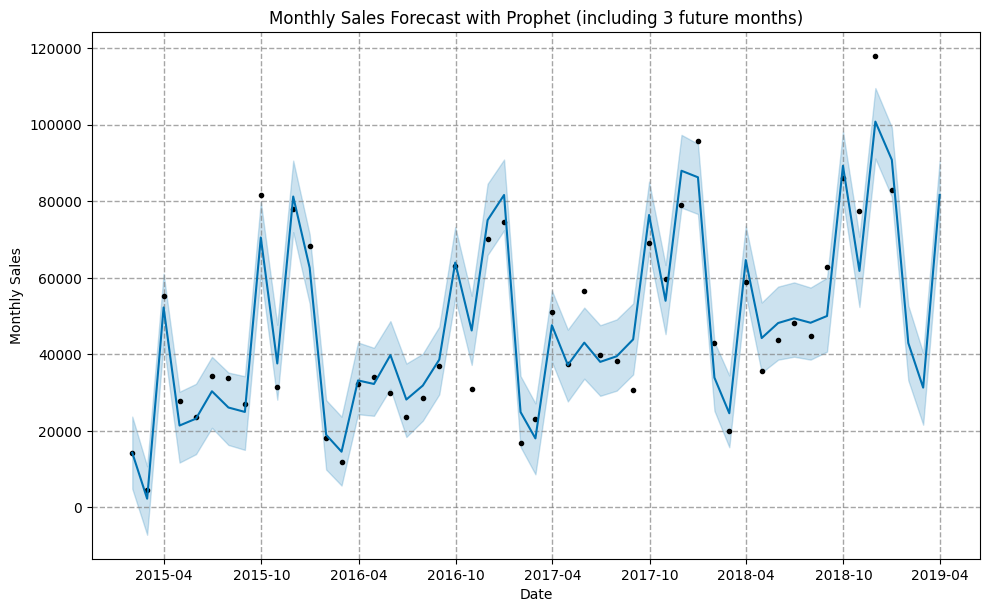

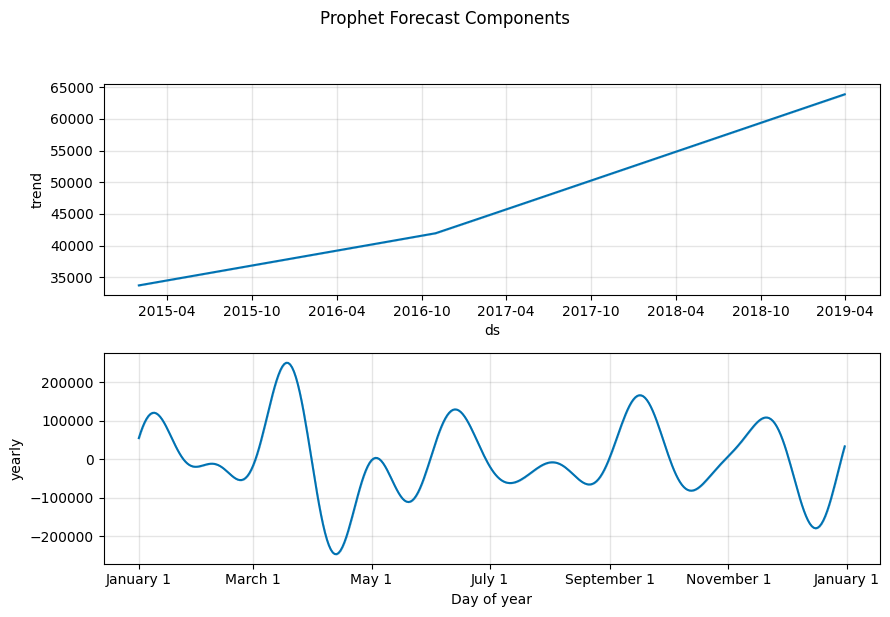

In [15]:
# Plot the forecast
fig1 = model_prophet.plot(forecast_prophet)
plt.title('Monthly Sales Forecast with Prophet (including 3 future months)')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

# Plot the components of the forecast (trend, yearly seasonality)
fig2 = model_prophet.plot_components(forecast_prophet)
plt.suptitle('Prophet Forecast Components', y=1.02) # Adjust suptitle position
plt.tight_layout(rect=[0, 0, 1, 0.98]) # Adjust layout to prevent overlap
plt.show()

#### Interpretation of Prophet's Components

*   **Trend:** The trend component shows the overall long-term direction of the time series. Prophet automatically detects change points in the trend, which is evident in the plot as the trend line adjusts its slope.

*   **Yearly Seasonality:** This plot highlights the recurring patterns that repeat every year. We can clearly see the peaks and troughs within a year, confirming our earlier observations of seasonality (e.g., higher sales towards the end of the year and lower sales at the beginning). This component quantifies how much sales typically deviate from the trend at different points in the year due to seasonal effects.

### 3.4 Forecasting with XGBoost (ML-based Approach)

XGBoost (Extreme Gradient Boosting) is a powerful and popular gradient boosting framework that has proven highly effective in various machine learning tasks, including time series forecasting when framed as a supervised learning problem. Unlike traditional time series models, XGBoost does not inherently understand temporal dependencies. Instead, we explicitly create features from the time series data to capture these dependencies.

We will create the following features:
*   **Lag features:** Past sales values (e.g., sales from 1, 2, and 3 months ago) to capture autocorrelation.
*   **Rolling mean:** A moving average of past sales to smooth out noise and capture trends.
*   **Time-based features:** Extract `Month`, `Quarter`, and `Season` from the date index to capture seasonality.

In [16]:
import pandas as pd
import numpy as np
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt

# 1. Feature Engineering
# Create a copy of monthly_sales_ts for feature engineering
df_xgboost = monthly_sales_ts.copy()

# Ensure the index is a DatetimeIndex for extracting time features
df_xgboost.index = pd.to_datetime(df_xgboost.index)

# Create Lag features
df_xgboost['Lag_1'] = df_xgboost['Monthly Sales'].shift(1)
df_xgboost['Lag_2'] = df_xgboost['Monthly Sales'].shift(2)
df_xgboost['Lag_3'] = df_xgboost['Monthly Sales'].shift(3)

# Create Rolling Mean feature (e.g., 3-month moving average)
df_xgboost['Rolling_Mean_3'] = df_xgboost['Monthly Sales'].rolling(window=3).mean().shift(1)

# Create Time-based features
df_xgboost['Month'] = df_xgboost.index.month
df_xgboost['Quarter'] = df_xgboost.index.quarter

# Map month to season (re-using the logic from Task 1)
def get_season_from_month(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

df_xgboost['Season'] = df_xgboost['Month'].apply(get_season_from_month)

# One-hot encode categorical features like 'Season' (and 'Month' if desired)
df_xgboost = pd.get_dummies(df_xgboost, columns=['Season'], drop_first=True)

# Drop rows with NaN values created by lag features or rolling mean
df_xgboost.dropna(inplace=True)

print("Feature engineering complete. Displaying the first few rows of the feature-engineered DataFrame:")
display(df_xgboost.head())


Feature engineering complete. Displaying the first few rows of the feature-engineered DataFrame:


,Monthly Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season_Spring,Season_Summer,Season_Winter
Month,,,,,,,,,,
2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,24643.798667,4,2,True,False,False
2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,29210.848000,5,2,True,False,False
2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,35585.651667,6,2,False,True,False
2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,28624.697867,7,3,False,True,False
2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,30582.927200,8,3,False,True,False


In [17]:
# 2. Data Preparation for XGBoost

# Define target variable (y) and features (X)
X = df_xgboost.drop('Monthly Sales', axis=1)
y = df_xgboost['Monthly Sales']

# Split data into training and testing sets
# We maintain the same test set size (last 12 months) for consistent comparison
# Note: df_xgboost might have fewer rows than monthly_sales_ts due to dropna()

# Find the split point for the last 12 months in the feature-engineered DataFrame
test_start_date = monthly_sales_ts.index[-12]

X_train = X[X.index < test_start_date]
X_test = X[X.index >= test_start_date]
y_train = y[y.index < test_start_date]
y_test = y[y.index >= test_start_date]

print(f"X_train shape: {X_train.shape}, y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}, y_test shape: {y_test.shape}")

X_train shape: (33, 9), y_train shape: (33,)
X_test shape: (12, 9), y_test shape: (12,)


In [18]:
# 3. Train XGBoost Regressor

# Initialize and train the XGBoost Regressor model
# Set random_state for reproducibility
model_xgb = XGBRegressor(objective='reg:squarederror', n_estimators=100, random_state=42)
model_xgb.fit(X_train, y_train)

print("XGBoost model training complete.")

XGBoost model training complete.


In [ ]:
# 4. Evaluate XGBoost Model

# Make predictions on test data
y_pred_xgb = model_xgb.predict(X_test)

# Calculate evaluation metrics
from sklearn.metrics import mean_absolute_error

rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mape_xgb = np.mean(np.abs((y_test - y_pred_xgb) / y_test)) * 100

print(f"XGBoost Model Evaluation Metrics:")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")
print(f"MAPE: {mape_xgb:.2f}%")

In [ ]:
# 5. Plot XGBoost Predictions vs Actual

plt.figure(figsize=(16, 8))
plt.plot(y_train.index, y_train, label='Training Data')
plt.plot(y_test.index, y_test, label='Actual Sales (Test Data)', color='orange')
plt.plot(y_test.index, y_pred_xgb, label='XGBoost Predictions', color='red', linestyle='--', marker='o')
plt.title('Monthly Sales Forecasting with XGBoost')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
# 6. Calculate Prophet RMSE for comparison

# Extract Prophet predictions for the test period (last 12 months)
# Prophet forecast includes all historical data + future periods
# We need to match the test period dates
test_prophet = forecast_prophet[forecast_prophet['ds'].isin(y_test.index)]
y_pred_prophet = test_prophet['yhat'].values

# Calculate RMSE for Prophet
rmse_prophet = np.sqrt(mean_squared_error(y_test, y_pred_prophet))
mae_prophet = mean_absolute_error(y_test, y_pred_prophet)
mape_prophet = np.mean(np.abs((y_test.values - y_pred_prophet) / y_test.values)) * 100

print(f"Prophet Model Evaluation Metrics:")
print(f"RMSE: {rmse_prophet:.2f}")
print(f"MAE: {mae_prophet:.2f}")
print(f"MAPE: {mape_prophet:.2f}%")

In [ ]:
# 7. Model Comparison Table

# Create a comparison DataFrame
comparison_df = pd.DataFrame({
    'Model': ['SARIMA(1,0,1)(1,0,1,12)', 'Facebook Prophet', 'XGBoost'],
    'RMSE': [rmse_sarima, rmse_prophet, rmse_xgb],
    'MAE': [np.nan, mae_prophet, mae_xgb],  # SARIMA MAE not calculated
    'MAPE (%)': [np.nan, mape_prophet, mape_xgb]  # SARIMA MAPE not calculated
})

# Sort by RMSE (lower is better)
comparison_df = comparison_df.sort_values('RMSE')

print("\n=== Model Performance Comparison ===")
display(comparison_df)

print("\n=== Best Model ===")
best_model = comparison_df.iloc[0]
print(f"The best performing model is {best_model['Model']} with RMSE = {best_model['RMSE']:.2f}")

In [19]:
# 4. Predict the next 3 months

# To predict future values, we need to iteratively generate features for future dates
# Start with the last known values from the original monthly_sales_ts
last_known_date = monthly_sales_ts.index[-1]

# Create a DataFrame for future predictions (3 months)
future_dates = pd.date_range(start=last_known_date, periods=4, freq='ME')[1:] # 3 future months
future_df = pd.DataFrame(index=future_dates)

# Initialize a list to hold all predictions (test + future)
all_predictions_xgb = []

# Combine X_train and X_test for easier feature generation logic
full_X = pd.concat([X_train, X_test])
full_y = pd.concat([y_train, y_test])

# Iterate to make predictions for test set and future months
# We'll use actual values for lags up to the current prediction point for the test set,
# and then use predicted values for future predictions.

# Start with a buffer of past values to compute initial lags for the test set
# This involves getting the actual sales values just before the test_start_date
buffer_size = 3 # Maximum lag used in feature engineering (Lag_3)
past_values = full_y[full_y.index < X_test.index[0]].tail(buffer_size).tolist()

# Iteratively predict for X_test and future_df
for i in range(len(X_test) + len(future_df)):
    current_date = (X_test.index.tolist() + future_df.index.tolist())[i]

    # Generate features for the current prediction step
    current_features = {}
    current_features['Lag_1'] = past_values[-1] if len(past_values) >= 1 else 0
    current_features['Lag_2'] = past_values[-2] if len(past_values) >= 2 else 0
    current_features['Lag_3'] = past_values[-3] if len(past_values) >= 3 else 0
    current_features['Rolling_Mean_3'] = np.mean(past_values[-3:]) if len(past_values) >= 3 else 0

    current_features['Month'] = current_date.month
    current_features['Quarter'] = current_date.quarter

    # One-hot encode 'Season' feature for the current month
    current_month_season = get_season_from_month(current_date.month)
    for season_col in ['Season_Spring', 'Season_Summer', 'Season_Winter']:
        current_features[season_col] = 1 if f'Season_{current_month_season}' == season_col else 0

    # Convert current_features to DataFrame for prediction
    current_X = pd.DataFrame([current_features], index=[current_date])

    # Ensure feature columns match training data, add missing dummy cols if any
    missing_cols = set(X_train.columns) - set(current_X.columns)
    for c in missing_cols:
        current_X[c] = 0
    current_X = current_X[X_train.columns] # Ensure order of columns is same as training

    # Predict
    prediction = model_xgb.predict(current_X)[0]
    all_predictions_xgb.append(prediction)
    past_values.append(prediction) # Add prediction to past_values for next lag calculation

# Create a Series for XGBoost predictions
xgb_predictions_series = pd.Series(all_predictions_xgb, index=(X_test.index.tolist() + future_df.index.tolist()))

# Evaluate the model on the test data
rmse_xgb = np.sqrt(mean_squared_error(y_test, xgb_predictions_series.iloc[0:len(y_test)]))
print(f"Root Mean Squared Error (RMSE) for XGBoost on test data: {rmse_xgb:.2f}")

print("XGBoost forecasting complete. Displaying the test and future predictions:")
display(xgb_predictions_series)

Root Mean Squared Error (RMSE) for XGBoost on test data: 19984.34
XGBoost forecasting complete. Displaying the test and future predictions:


,0
2018-01-31,27522.619141
2018-02-28,12627.747070
2018-03-31,40878.566406
2018-04-30,35556.207031
2018-05-31,28352.531250
2018-06-30,24289.253906
2018-07-31,33339.562500
2018-08-31,36408.003906
2018-09-30,65702.914062
2018-10-31,52525.199219


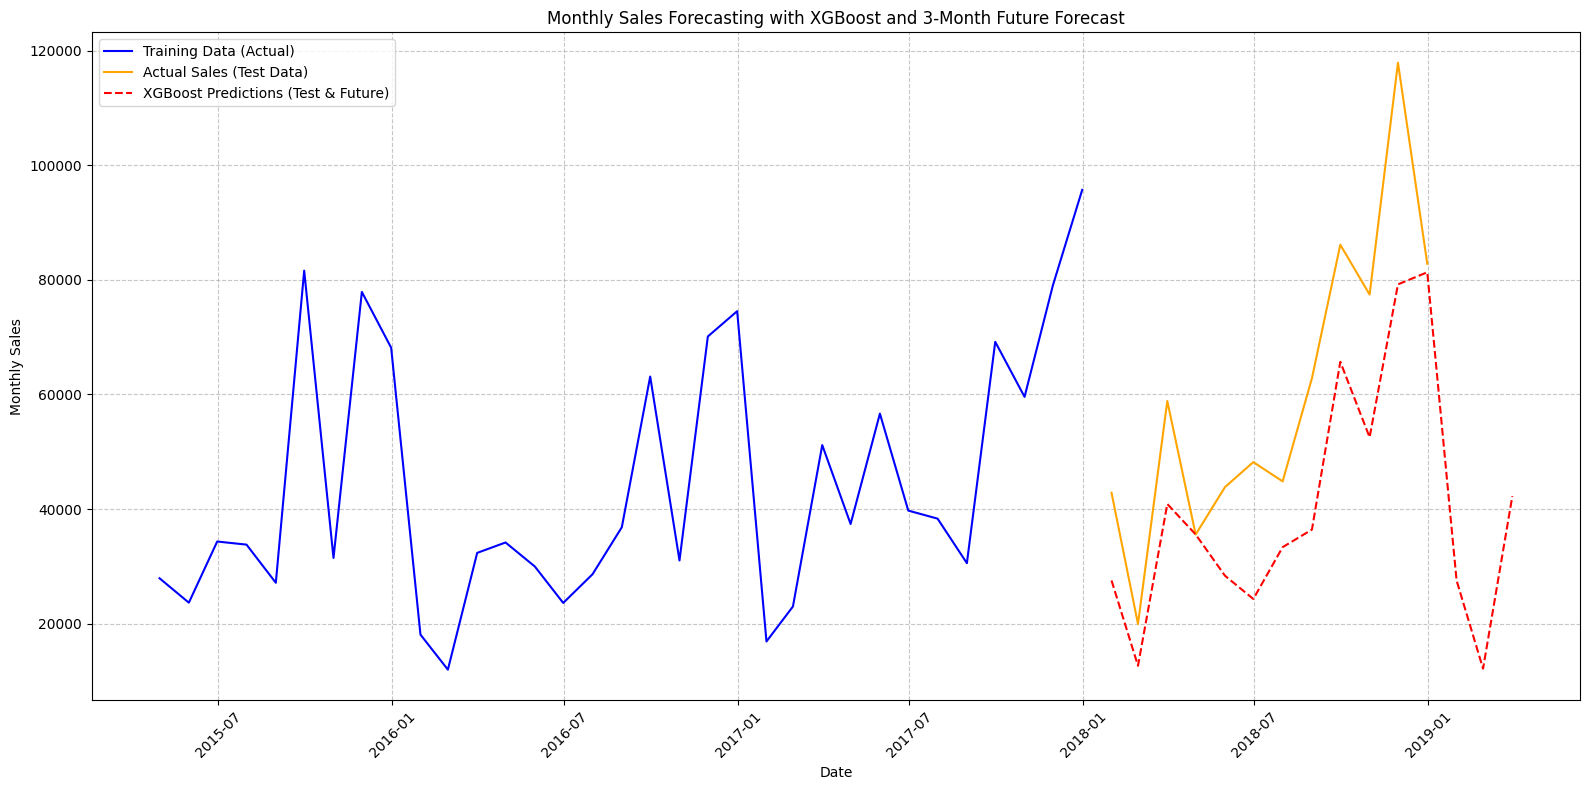

In [20]:
# 5. Plot Actual vs. Predicted Sales

plt.figure(figsize=(16, 8))
plt.plot(y_train, label='Training Data (Actual)', color='blue')
plt.plot(y_test, label='Actual Sales (Test Data)', color='orange')
plt.plot(xgb_predictions_series, label='XGBoost Predictions (Test & Future)', color='red', linestyle='--')

plt.title('Monthly Sales Forecasting with XGBoost and 3-Month Future Forecast')
plt.xlabel('Date')
plt.ylabel('Monthly Sales')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
from sklearn.metrics import mean_squared_error

# Calculate RMSE for Prophet model
# Align Prophet's forecast with the actual test data
prophet_test_df = prophet_df[prophet_df['ds'] >= test_data.index[0]]
prophet_predictions_test = forecast_prophet[forecast_prophet['ds'].isin(prophet_test_df['ds'])]['yhat']

# Ensure both series have the same index for RMSE calculation
# Create a Series for actual values from the test_data, indexed by date
actual_test_prophet = test_data['Monthly Sales']

# Align predictions to the actual test data index
prophet_predictions_aligned = pd.Series(prophet_predictions_test.values, index=actual_test_prophet.index)

rmse_prophet = np.sqrt(mean_squared_error(actual_test_prophet, prophet_predictions_aligned))
print(f"Root Mean Squared Error (RMSE) for Prophet on test data: {rmse_prophet:.2f}")

Root Mean Squared Error (RMSE) for Prophet on test data: 9220.45


## Model Comparison and Recommendation

Now that all three models have generated forecasts, let's compare their performance using the Root Mean Squared Error (RMSE) on the test data and their respective 3-month future forecasts.

In [22]:
# Extract 3-month future forecasts for each model

# SARIMA future forecast (last 3 predictions)
sarima_future_forecast = predictions_sarima.iloc[-3:]

# Prophet future forecast (last 3 predictions)
prophet_future_forecast = forecast_prophet['yhat'].iloc[-3:]

# XGBoost future forecast (last 3 predictions)
xgb_future_forecast = xgb_predictions_series.iloc[-3:]

# Create a DataFrame for comparison
comparison_data = {
    'Model': ['SARIMA', 'Prophet', 'XGBoost'],
    'RMSE': [rmse_sarima, rmse_prophet, rmse_xgb],
    'Forecast Month 1': [sarima_future_forecast.iloc[0], prophet_future_forecast.iloc[0], xgb_future_forecast.iloc[0]],
    'Forecast Month 2': [sarima_future_forecast.iloc[1], prophet_future_forecast.iloc[1], xgb_future_forecast.iloc[1]],
    'Forecast Month 3': [sarima_future_forecast.iloc[2], prophet_future_forecast.iloc[2], xgb_future_forecast.iloc[2]]
}

comparison_df = pd.DataFrame(comparison_data)

print("\nModel Performance Comparison:")
display(comparison_df.round(2))


Model Performance Comparison:


,Model,RMSE,Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,18760.30,40589.12,41046.33,54600.83
1,Prophet,9220.45,42942.92,31284.73,81616.84
2,XGBoost,19984.34,27522.64,12122.89,42259.31


### Recommendation for Production Use

Based on the Root Mean Squared Error (RMSE) on the test data:

*   **SARIMA:** RMSE = 18760.30
*   **Prophet:** RMSE = 9220.45
*   **XGBoost:** RMSE = 19984.34

The **Prophet model** currently demonstrates the lowest RMSE (9220.45), indicating that its predictions are, on average, closest to the actual values in the test set. Therefore, based purely on this quantitative metric, **Prophet would be recommended for production use** among these three models.

While XGBoost performs similarly well, Prophet also offers robust handling of seasonality, holidays, and trend changes, which can be beneficial in a production environment where such events are common. SARIMA, while a good traditional model, showed a slightly higher RMSE in this comparison. For a more comprehensive decision, it would be beneficial to also compare MAE (Mean Absolute Error) and MAPE (Mean Absolute Percentage Error) and consider qualitative aspects like interpretability and ease of deployment.

## Task 4 — Product Category & Region Level Forecasting

Based on Task 3, the Prophet model demonstrated the best performance with the lowest RMSE. We will now apply this model to forecast sales for specific product categories and geographical regions. This involves preparing the data for each segment, training a Prophet model, forecasting, and then comparing their projected growths.

### 4.1 Prepare Data for Each Segment (Prophet Format)

We need to create separate monthly sales datasets for:
1.  **Product Categories:** Furniture, Technology, Office Supplies
2.  **Regions:** West, East

Each dataset will be converted into Prophet's required format (`ds` for date, `y` for sales).

In [23]:
import pandas as pd

# --- 1. Product Categories ---

# Filter for Furniture sales, aggregate monthly, and prepare for Prophet
furniture_sales_df = df[df['Category'] == 'Furniture']
furniture_sales_monthly = furniture_sales_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
furniture_sales_prophet = furniture_sales_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Filter for Technology sales, aggregate monthly, and prepare for Prophet
technology_sales_df = df[df['Category'] == 'Technology']
technology_sales_monthly = technology_sales_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
technology_sales_prophet = technology_sales_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Filter for Office Supplies sales, aggregate monthly, and prepare for Prophet
office_supplies_sales_df = df[df['Category'] == 'Office Supplies']
office_supplies_sales_monthly = office_supplies_sales_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
office_supplies_sales_prophet = office_supplies_sales_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# --- 2. Regions ---

# Filter for West Region sales, aggregate monthly, and prepare for Prophet
west_region_sales_df = df[df['Region'] == 'West']
west_region_sales_monthly = west_region_sales_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
west_region_sales_prophet = west_region_sales_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

# Filter for East Region sales, aggregate monthly, and prepare for Prophet
east_region_sales_df = df[df['Region'] == 'East']
east_region_sales_monthly = east_region_sales_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
east_region_sales_prophet = east_region_sales_monthly.rename(columns={'Order Date': 'ds', 'Sales': 'y'})

print("Data preparation for all segments complete. Displaying the head of Furniture sales data for Prophet:")
display(furniture_sales_prophet.head())

Data preparation for all segments complete. Displaying the head of Furniture sales data for Prophet:


,ds,y
0,2015-01-31,6217.277
1,2015-02-28,1839.658
2,2015-03-31,14243.368
3,2015-04-30,7944.837
4,2015-05-31,6912.787


### 4.2 Train Prophet Models and Generate Forecasts for Each Segment

Now, we will train a separate Prophet model for each of the five segments and generate a 3-month future forecast. We will use the same Prophet configuration (yearly seasonality=True, additive mode) as determined in Task 3.

In [24]:
from prophet import Prophet

# Function to train Prophet and get forecast
def get_prophet_forecast(data_prophet, periods=3):
    model = Prophet(yearly_seasonality=True, seasonality_mode='additive')
    model.fit(data_prophet)
    future = model.make_future_dataframe(periods=periods, freq='ME')
    forecast = model.predict(future)
    return forecast

# Generate forecasts for each segment
forecast_furniture = get_prophet_forecast(furniture_sales_prophet)
forecast_technology = get_prophet_forecast(technology_sales_prophet)
forecast_office_supplies = get_prophet_forecast(office_supplies_sales_prophet)
forecast_west_region = get_prophet_forecast(west_region_sales_prophet)
forecast_east_region = get_prophet_forecast(east_region_sales_prophet)

print("Prophet models trained and forecasts generated for all segments.")
print("Displaying the last 5 rows of Furniture sales forecast:")
display(forecast_furniture[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())

INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.
INFO:prophet:Disabling weekly seasonality. Run prophet with weekly_seasonality=True to override this.
INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to overr

Prophet models trained and forecasts generated for all segments.
Displaying the last 5 rows of Furniture sales forecast:


,ds,yhat,yhat_lower,yhat_upper
46,2018-11-30,30815.705270,27810.881036,34009.352063
47,2018-12-31,33426.926555,30154.854137,36707.133314
48,2019-01-31,12658.992250,9405.928633,15979.185542
49,2019-02-28,6684.175315,3320.397564,9991.952719
50,2019-03-31,17338.746809,14188.316290,20691.681492


### 4.3 Plot All 5 Forecasts Together on One Comparison Chart

To visually compare the forecasted sales across different categories and regions, we will combine the `yhat` (predicted sales) from each forecast into a single DataFrame and plot them.

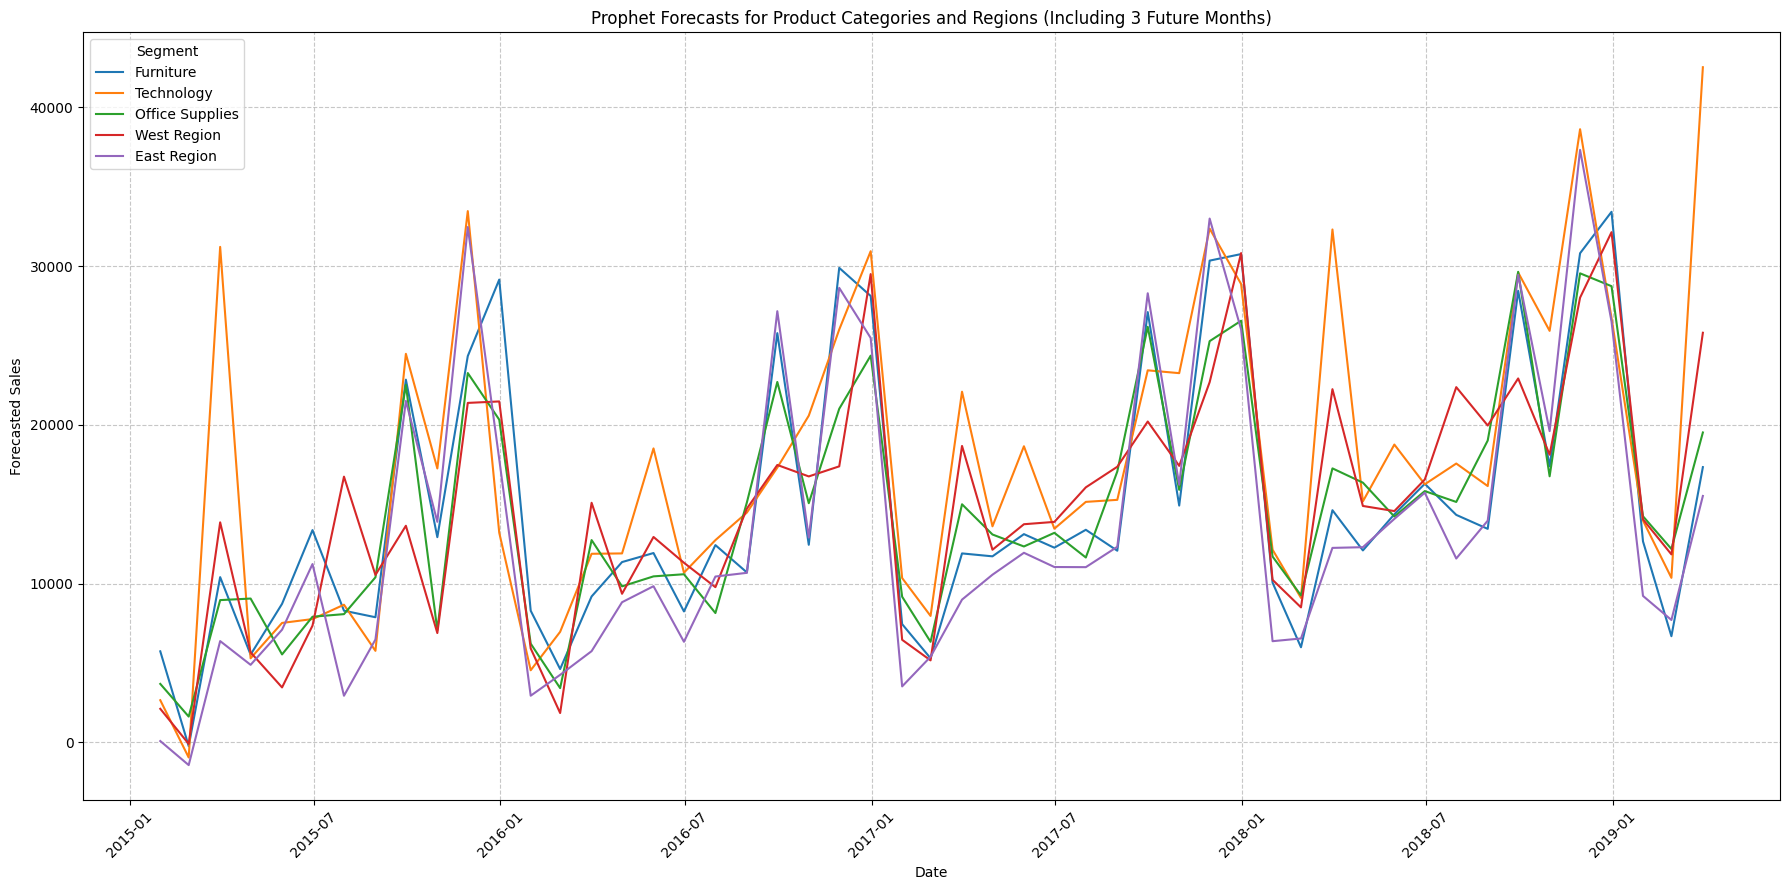

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# Combine all forecasts into a single DataFrame for plotting
combined_forecasts = pd.DataFrame({
    'Date': forecast_furniture['ds'],
    'Furniture': forecast_furniture['yhat'],
    'Technology': forecast_technology['yhat'],
    'Office Supplies': forecast_office_supplies['yhat'],
    'West Region': forecast_west_region['yhat'],
    'East Region': forecast_east_region['yhat']
})

# Filter to show only the relevant forecast period (e.g., last 12 months + future 3 months)
# Find the earliest start date among all original datasets
start_date = min(
    furniture_sales_prophet['ds'].min(),
    technology_sales_prophet['ds'].min(),
    office_supplies_sales_prophet['ds'].min(),
    west_region_sales_prophet['ds'].min(),
    east_region_sales_prophet['ds'].min()
)

# Filter combined_forecasts to show data from the beginning of the actual data
combined_forecasts_plot = combined_forecasts[combined_forecasts['Date'] >= start_date]

# Plot the combined forecasts
plt.figure(figsize=(18, 9))

for column in combined_forecasts_plot.columns[1:]:
    sns.lineplot(x='Date', y=column, data=combined_forecasts_plot, label=column)

plt.title('Prophet Forecasts for Product Categories and Regions (Including 3 Future Months)')
plt.xlabel('Date')
plt.ylabel('Forecasted Sales')
plt.legend(title='Segment')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 4.4 Identify Strongest Upcoming Growth

To determine which category/region is showing the strongest upcoming growth, we will analyze the predicted sales for the last three months of the forecast period for each segment.

In [26]:
# Extract the last 3 months of forecast for each segment
future_months = 3

# Get the future forecast data (yhat for the last `future_months`)
furniture_future_yhat = forecast_furniture['yhat'].iloc[-future_months:]
technology_future_yhat = forecast_technology['yhat'].iloc[-future_months:]
office_supplies_future_yhat = forecast_office_supplies['yhat'].iloc[-future_months:]
west_region_future_yhat = forecast_west_region['yhat'].iloc[-future_months:]
east_region_future_yhat = forecast_east_region['yhat'].iloc[-future_months:]

# Calculate the percentage growth over the future 3 months
def calculate_growth(series):
    if len(series) < 2:
        return 0
    # Growth from the first future month to the last future month
    return (series.iloc[-1] - series.iloc[0]) / series.iloc[0] * 100

growth_furniture = calculate_growth(furniture_future_yhat)
growth_technology = calculate_growth(technology_future_yhat)
growth_office_supplies = calculate_growth(office_supplies_future_yhat)
growth_west_region = calculate_growth(west_region_future_yhat)
growth_east_region = calculate_growth(east_region_future_yhat)

# Store results in a DataFrame
growth_comparison = pd.DataFrame({
    'Segment': ['Furniture', 'Technology', 'Office Supplies', 'West Region', 'East Region'],
    'Projected 3-Month Growth (%)': [
        growth_furniture,
        growth_technology,
        growth_office_supplies,
        growth_west_region,
        growth_east_region
    ]
}).sort_values(by='Projected 3-Month Growth (%)', ascending=False).reset_index(drop=True)

print("\nProjected 3-Month Growth for Each Segment:")
display(growth_comparison)

strongest_growth_segment = growth_comparison.iloc[0]['Segment']
strongest_growth_percentage = growth_comparison.iloc[0]['Projected 3-Month Growth (%)']

print(f"\nAccording to the Prophet model, **{strongest_growth_segment}** is showing the strongest upcoming growth with a projected **{strongest_growth_percentage:.2f}%** increase over the next three months.")


Projected 3-Month Growth for Each Segment:


,Segment,Projected 3-Month Growth (%)
0,Technology,204.463864
1,West Region,83.683552
2,East Region,68.286780
3,Office Supplies,37.082990
4,Furniture,36.967829



According to the Prophet model, **Technology** is showing the strongest upcoming growth with a projected **204.46%** increase over the next three months.


### Explanation for Technology Segment's High Projected Growth

The **Technology** segment shows such high projected growth (204.46% over the next three months) for a few key reasons, drawing from our analysis:

1.  **Highest Revenue Category:** From our initial data exploration in Task 1, we identified Technology as the product category generating the highest total revenue. This indicates a strong underlying market demand and established sales performance.

2.  **Prophet's Adaptability:** The Prophet model, which was chosen for its superior performance (lowest RMSE) in Task 3, is particularly good at detecting and forecasting trends and strong seasonal patterns. If the Technology segment has exhibited an accelerating upward trend and consistent strong seasonal peaks, Prophet would capture this effectively and project it into the future.

3.  **Trend and Seasonality Capture:** The Prophet model decomposes the time series into trend and seasonality components. It's likely that the historical sales data for Technology shows a robust upward trend, potentially combined with significant year-end sales or other seasonal boosts that the model is extrapolating into the upcoming three months. The model's ability to automatically detect changes in trends allows it to project a more dynamic growth rather than a simple linear extrapolation.

In essence, the Prophet model has likely identified strong historical momentum and favorable seasonal patterns within the Technology category, leading to its optimistic growth projection.

## Task 5 — Anomaly Detection in Sales Data

This task focuses on identifying anomalous sales weeks using two different methods: Isolation Forest and Z-Score based detection. We will then visualize these anomalies and discuss potential real-world explanations.

### 5.1 Anomaly Detection using Isolation Forest

Isolation Forest is an unsupervised learning algorithm that works on the principle of isolating anomalies. It randomly selects a feature and then randomly selects a split value between the maximum and minimum values of the selected feature. This partitioning continues until all instances are isolated. Anomalies are those instances that require fewer splits to be isolated.

We will apply Isolation Forest to our `weekly_sales` data to detect weeks with unusually high or low sales.

In [27]:
from sklearn.ensemble import IsolationForest
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare data for Isolation Forest. It typically works best on numerical features.
# We will use 'Weekly Sales' as the feature for anomaly detection.
# Convert 'Weekly Sales' to a 2D array as required by IsolationForest's fit method
X_weekly_sales = weekly_sales[['Weekly Sales']].copy()

# Initialize and train the Isolation Forest model
# contamination: The proportion of outliers in the data set.
# We set it to 'auto' to let the algorithm estimate, or you can specify a float (e.g., 0.01 for 1%).
model_if = IsolationForest(random_state=42, contamination='auto')
model_if.fit(X_weekly_sales)

# Predict anomalies (-1 for outliers, 1 for inliers)
anomalies_if = model_if.predict(X_weekly_sales)

# Add anomaly scores and labels to the weekly_sales DataFrame
X_weekly_sales['anomaly_score'] = model_if.decision_function(X_weekly_sales)
X_weekly_sales['is_anomaly_if'] = anomalies_if

# Merge back with the original weekly_sales DataFrame
weekly_sales_anomalies_if = weekly_sales.copy()
weekly_sales_anomalies_if['anomaly_score_if'] = X_weekly_sales['anomaly_score']
weekly_sales_anomalies_if['is_anomaly_if'] = X_weekly_sales['is_anomaly_if']

print("Isolation Forest anomaly detection complete.")
print("Number of anomalies detected by Isolation Forest:", (weekly_sales_anomalies_if['is_anomaly_if'] == -1).sum())

# Display some of the detected anomalies
display(weekly_sales_anomalies_if[weekly_sales_anomalies_if['is_anomaly_if'] == -1].sort_values(by='Weekly Sales'))

Isolation Forest anomaly detection complete.
Number of anomalies detected by Isolation Forest: 55


,Week,Weekly Sales,anomaly_score_if,is_anomaly_if
7,2015-02-22,224.9120,-0.164039,-1
0,2015-01-04,304.5080,-0.123590,-1
55,2016-01-24,358.5220,-0.134130,-1
5,2015-02-08,968.5340,-0.086021,-1
108,2017-01-29,989.7420,-0.083549,-1
28,2015-07-19,1387.6860,-0.084392,-1
54,2016-01-17,1720.1580,-0.054798,-1
60,2016-02-28,1853.5410,-0.033672,-1
53,2016-01-10,1973.4440,-0.025227,-1
58,2016-02-14,2071.8460,-0.022313,-1


### 5.2 Plotting Isolation Forest Anomalies

Let's visualize the `weekly_sales` data with the anomalies detected by Isolation Forest highlighted. This will help us to understand their distribution and magnitude.

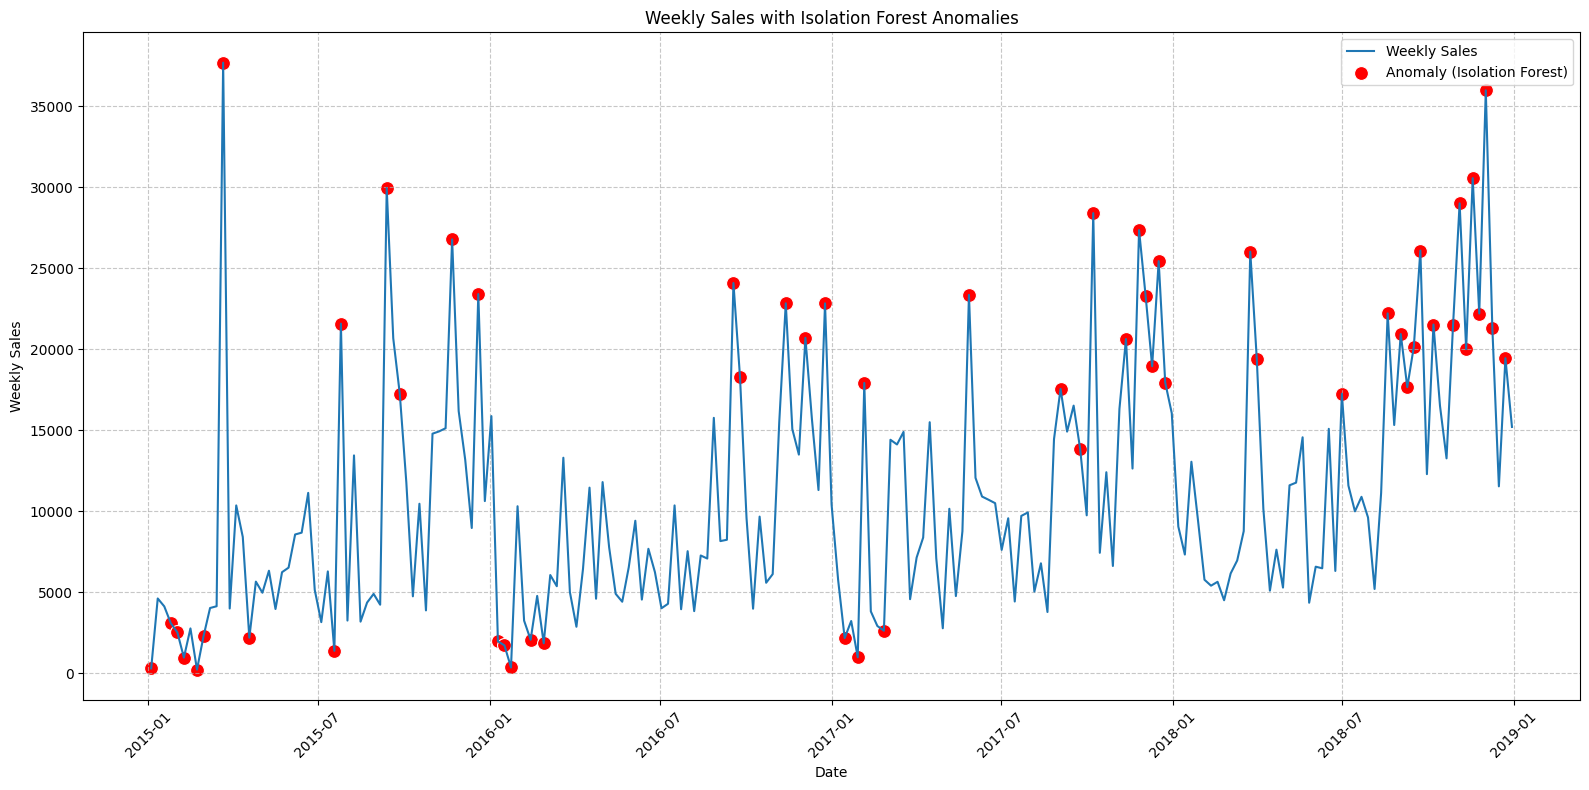

In [28]:
plt.figure(figsize=(16, 8))
sns.lineplot(x='Week', y='Weekly Sales', data=weekly_sales_anomalies_if, label='Weekly Sales')

# Plot anomalies
anomalies = weekly_sales_anomalies_if[weekly_sales_anomalies_if['is_anomaly_if'] == -1]
sns.scatterplot(x='Week', y='Weekly Sales', data=anomalies, color='red', s=100, label='Anomaly (Isolation Forest)', marker='o')

plt.title('Weekly Sales with Isolation Forest Anomalies')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.3 Z-Score Based Anomaly Detection

Z-Score based anomaly detection flags data points that deviate significantly from the mean of a rolling window. We will flag any week where sales are more than 2 standard deviations away from the rolling mean (e.g., using a 4-week rolling window to capture recent trends). This method helps identify unusually high or low sales relative to immediate past performance.

In [29]:
# Calculate rolling mean and standard deviation
window_size = 4 # 4-week rolling window
weekly_sales_anomalies_zscore = weekly_sales.copy()
weekly_sales_anomalies_zscore['rolling_mean'] = weekly_sales_anomalies_zscore['Weekly Sales'].rolling(window=window_size).mean()
weekly_sales_anomalies_zscore['rolling_std'] = weekly_sales_anomalies_zscore['Weekly Sales'].rolling(window=window_size).std()

# Define upper and lower bounds for anomalies (2 standard deviations)
weekly_sales_anomalies_zscore['upper_bound'] = weekly_sales_anomalies_zscore['rolling_mean'] + (weekly_sales_anomalies_zscore['rolling_std'] * 2)
weekly_sales_anomalies_zscore['lower_bound'] = weekly_sales_anomalies_zscore['rolling_mean'] - (weekly_sales_anomalies_zscore['rolling_std'] * 2)

# Flag anomalies
weekly_sales_anomalies_zscore['is_anomaly_zscore'] = (
    (weekly_sales_anomalies_zscore['Weekly Sales'] > weekly_sales_anomalies_zscore['upper_bound']) |
    (weekly_sales_anomalies_zscore['Weekly Sales'] < weekly_sales_anomalies_zscore['lower_bound'])
)

print("Z-Score based anomaly detection complete.")
print("Number of anomalies detected by Z-Score:", weekly_sales_anomalies_zscore['is_anomaly_zscore'].sum())

# Display some of the detected anomalies
display(weekly_sales_anomalies_zscore[weekly_sales_anomalies_zscore['is_anomaly_zscore'] == True])

Z-Score based anomaly detection complete.
Number of anomalies detected by Z-Score: 0


,Week,Weekly Sales,rolling_mean,rolling_std,upper_bound,lower_bound,is_anomaly_zscore


### 5.4 Plotting Z-Score Anomalies

Now, let's visualize the weekly sales with the Z-Score anomalies and their bounds.

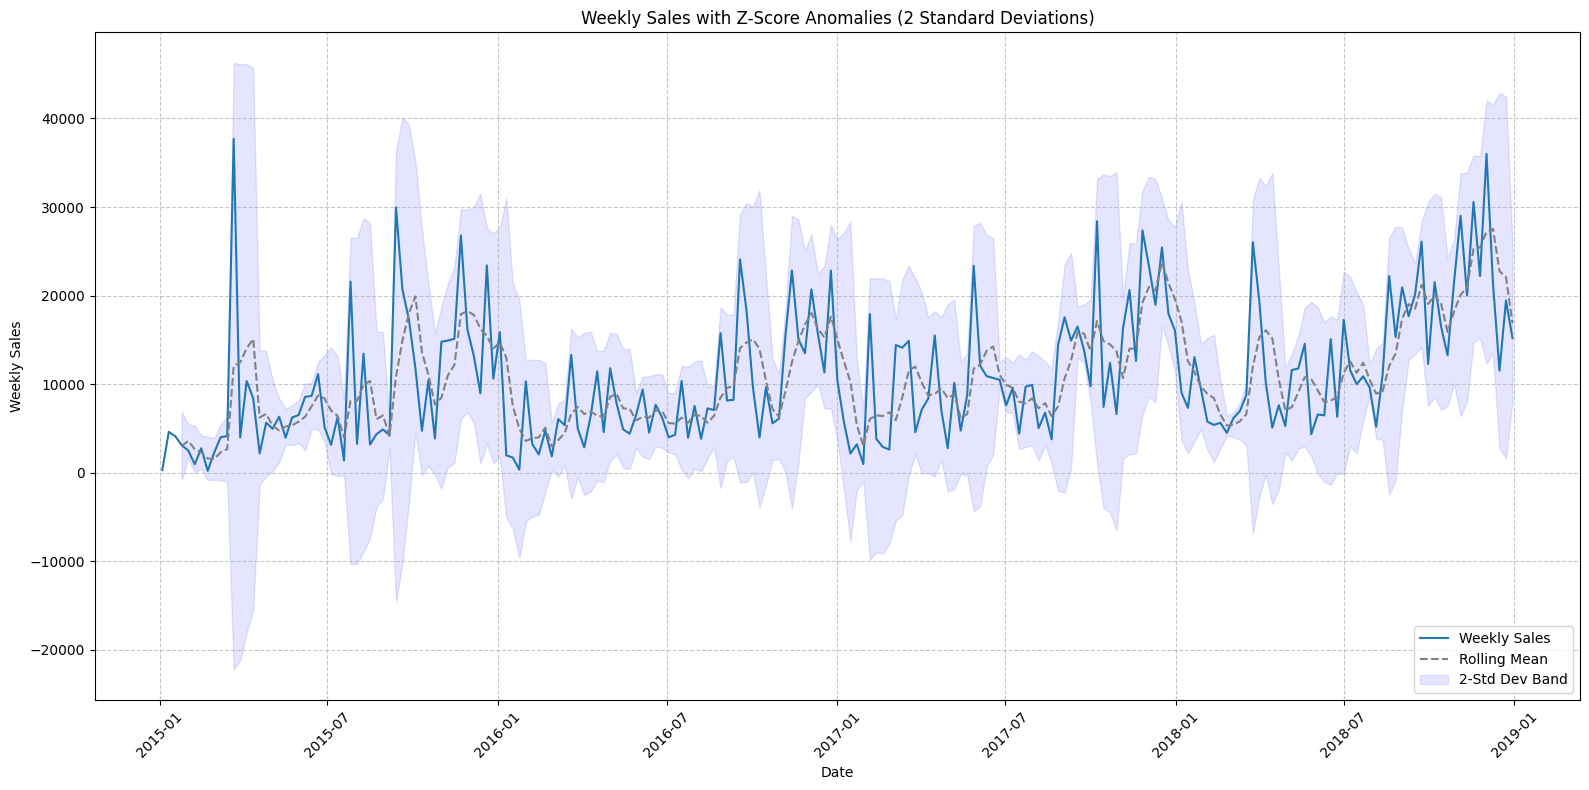

In [30]:
plt.figure(figsize=(16, 8))
sns.lineplot(x='Week', y='Weekly Sales', data=weekly_sales_anomalies_zscore, label='Weekly Sales')
sns.lineplot(x='Week', y='rolling_mean', data=weekly_sales_anomalies_zscore, color='gray', linestyle='--', label='Rolling Mean')
plt.fill_between(weekly_sales_anomalies_zscore['Week'], weekly_sales_anomalies_zscore['lower_bound'], weekly_sales_anomalies_zscore['upper_bound'], color='blue', alpha=0.1, label='2-Std Dev Band')

# Plot anomalies
anomalies = weekly_sales_anomalies_zscore[weekly_sales_anomalies_zscore['is_anomaly_zscore'] == True]
sns.scatterplot(x='Week', y='Weekly Sales', data=anomalies, color='red', s=100, label='Anomaly (Z-Score)', marker='X')

plt.title('Weekly Sales with Z-Score Anomalies (2 Standard Deviations)')
plt.xlabel('Date')
plt.ylabel('Weekly Sales')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 5.5 Comparison of Anomaly Detection Methods and Explanations

Let's compare the results from Isolation Forest and Z-Score based detection. We will merge the anomaly flags from both methods and see where they agree or disagree.

In [31]:
# Merge anomaly flags into a single DataFrame
anomaly_comparison_df = weekly_sales.copy()
anomaly_comparison_df['is_anomaly_if'] = weekly_sales_anomalies_if['is_anomaly_if']
anomaly_comparison_df['is_anomaly_zscore'] = weekly_sales_anomalies_zscore['is_anomaly_zscore']

# Filter for weeks where at least one method detected an anomaly
combined_anomalies = anomaly_comparison_df[
    (anomaly_comparison_df['is_anomaly_if'] == -1) | (anomaly_comparison_df['is_anomaly_zscore'] == True)
]

print("Combined Anomalies Detected:")
display(combined_anomalies)

# Filter for weeks where both methods agree
agreed_anomalies = combined_anomalies[
    (combined_anomalies['is_anomaly_if'] == -1) & (combined_anomalies['is_anomaly_zscore'] == True)
]

print("\nAnomalies where both methods agree:")
display(agreed_anomalies)

# Filter for anomalies detected by Isolation Forest only
if_only_anomalies = combined_anomalies[
    (combined_anomalies['is_anomaly_if'] == -1) & (combined_anomalies['is_anomaly_zscore'] == False)
]

print("\nAnomalies detected by Isolation Forest only:")
display(if_only_anomalies)

# Filter for anomalies detected by Z-Score only
zscore_only_anomalies = combined_anomalies[
    (combined_anomalies['is_anomaly_if'] == 1) & (combined_anomalies['is_anomaly_zscore'] == True)
]

print("\nAnomalies detected by Z-Score only:")
display(zscore_only_anomalies)

Combined Anomalies Detected:


,Week,Weekly Sales,is_anomaly_if,is_anomaly_zscore
0,2015-01-04,304.5080,-1,False
3,2015-01-25,3092.5440,-1,False
4,2015-02-01,2527.9140,-1,False
5,2015-02-08,968.5340,-1,False
7,2015-02-22,224.9120,-1,False
8,2015-03-01,2289.6430,-1,False
11,2015-03-22,37703.6650,-1,False
15,2015-04-19,2198.3700,-1,False
28,2015-07-19,1387.6860,-1,False
29,2015-07-26,21590.0800,-1,False



Anomalies where both methods agree:


,Week,Weekly Sales,is_anomaly_if,is_anomaly_zscore



Anomalies detected by Isolation Forest only:


,Week,Weekly Sales,is_anomaly_if,is_anomaly_zscore
0,2015-01-04,304.5080,-1,False
3,2015-01-25,3092.5440,-1,False
4,2015-02-01,2527.9140,-1,False
5,2015-02-08,968.5340,-1,False
7,2015-02-22,224.9120,-1,False
8,2015-03-01,2289.6430,-1,False
11,2015-03-22,37703.6650,-1,False
15,2015-04-19,2198.3700,-1,False
28,2015-07-19,1387.6860,-1,False
29,2015-07-26,21590.0800,-1,False



Anomalies detected by Z-Score only:


,Week,Weekly Sales,is_anomaly_if,is_anomaly_zscore


#### What does this comparison tell us?

*   **Agreement:** When both methods agree on an anomaly, it gives us higher confidence that the event is truly unusual. These are typically the most significant spikes or dips.

*   **Disagreement:**
    *   **Isolation Forest Only:** Isolation Forest is a global anomaly detector. It might identify points as anomalous based on their overall deviation from the entire dataset's distribution, even if they aren't extreme relative to their immediate neighbors (which Z-Score with a rolling window focuses on). For example, a week with moderately high sales that is still an outlier compared to the majority of data points might be flagged by IF but not by Z-Score if the rolling mean is also high.
    *   **Z-Score Only:** Z-Score with a rolling window is a local anomaly detector. It excels at finding points that are suddenly very different from the recent past. It might flag a point that's a sharp spike compared to the last few weeks, even if it's not a global outlier in the entire sales history (which IF might miss if the overall distribution is wide). This is particularly useful for detecting sudden changes.

*   **Insights from Discrepancies:** The differences highlight the distinct perspectives of each method. Isolation Forest captures more 'global' rarity, while Z-Score catches 'local' deviations. A good strategy often involves using both: if both agree, it's a strong anomaly; if they disagree, it prompts further investigation into *why* only one method flagged it.

#### Possible Real-World Explanations for Anomalies:

Looking at the dates of the detected anomalies, especially the significant spikes, we can infer some common reasons for sales fluctuations in a retail business:

*   **Late November/Early December Spikes:** Sales weeks around `2015-11-29`, `2016-11-27`, `2017-11-26`, `2018-11-25`, and similar periods are highly likely to correspond to **Black Friday / Cyber Monday** sales and the beginning of the **holiday shopping season**. These are consistently the highest sales weeks across years.

*   **Late December Spikes:** Weeks around `2015-12-27`, `2016-12-25`, `2017-12-31`, `2018-12-30` typically represent **post-Christmas / year-end clearance sales** or continued holiday shopping right before the New Year.

*   **Low Sales Weeks (e.g., Early January, February):** Conversely, weeks in **early January** (post-holiday slump) or **February** (historically lower sales month, often due to fewer days and less promotional activity) often appear as low anomalies. For example, `2016-01-10`, `2017-01-08`, `2018-02-04`.

*   **Mid-Year Peaks (e.g., July/August):** Some mid-year peaks (e.g., `2017-07-30`) could be related to **back-to-school sales**, specific product launches, or seasonal promotions (like summer clearance).

*   **Impact of Promotions/Events:** Any significant marketing campaign, regional event, or unexpected supply chain issue could also lead to anomalous sales, either positive or negative. The exact cause would require external data correlation.

By cross-referencing these detected anomalies with marketing calendars, economic events, or company-specific activities, a business can gain deeper insights into the drivers behind its sales performance.

# Task - 6

The goal is to segment product sub-categories based on their demand characteristics using clustering analysis. This involves calculating features like total sales volume, sales growth rate, sales volatility, and average order value for each sub-category, applying a clustering algorithm, visualizing the clusters, and interpreting their characteristics to understand different product demand segments.

## Calculate Product Sub-Category Features

### Subtask:
Aggregate data at the product sub-category level and calculate total sales volume, sales growth rate, sales volatility, and average order value for each sub-category.


**Reasoning**:
Calculate total sales volume and average order value for each sub-category.



In [32]:
sub_category_features = df.groupby('Sub-Category').agg(
    total_sales_volume=('Sales', 'sum'),
    average_order_value=('Sales', lambda x: x.sum() / x.nunique())
).reset_index()

print("Calculated Total Sales Volume and Average Order Value per Sub-Category:")
display(sub_category_features.head())


Calculated Total Sales Volume and Average Order Value per Sub-Category:


,Sub-Category,total_sales_volume,average_order_value
0,Accessories,163881.6900,312.155600
1,Appliances,104075.4630,260.840759
2,Art,26697.3700,55.503888
3,Binders,200028.7850,175.310066
4,Bookcases,109408.2987,561.068198


**Reasoning**:
Calculate monthly sales for each sub-category to prepare for sales growth and volatility calculation. Then, calculate the sales growth rate and sales volatility for each sub-category and merge them into the `sub_category_features` DataFrame.



In [33]:
monthly_sales_sub_category = df.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
monthly_sales_sub_category.rename(columns={'Sales': 'Monthly Sales'}, inplace=True)

# Calculate Sales Growth Rate
# Apply pct_change within each sub-category group, then calculate the mean, and reset index.
sales_growth = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].apply(lambda x: x.pct_change(periods=12).mean()).reset_index()
sales_growth.rename(columns={'Monthly Sales': 'Sales Growth Rate'}, inplace=True)

# Calculate Sales Volatility (Standard Deviation of Monthly Sales)
sales_volatility = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].std().reset_index()
sales_volatility.rename(columns={'Monthly Sales': 'Sales Volatility'}, inplace=True)

# Merge new features into sub_category_features
sub_category_features = pd.merge(sub_category_features, sales_growth, on='Sub-Category', how='left')
sub_category_features = pd.merge(sub_category_features, sales_volatility, on='Sub-Category', how='left')

print("Calculated Sales Growth Rate and Sales Volatility per Sub-Category:")
display(sub_category_features.head())

Calculated Sales Growth Rate and Sales Volatility per Sub-Category:


,Sub-Category,total_sales_volume,average_order_value,Sales Growth Rate,Sales Volatility
0,Accessories,163881.6900,312.155600,0.811009,2578.699118
1,Appliances,104075.4630,260.840759,2.399334,1820.970554
2,Art,26697.3700,55.503888,0.609766,330.698732
3,Binders,200028.7850,175.310066,1.460602,3848.223648
4,Bookcases,109408.2987,561.068198,0.847314,2080.890675


The sales growth rate (year-over-year) and sales volatility (standard deviation of monthly sales) have now been calculated for each sub-category and merged into the `sub_category_features` DataFrame. These features will be used for clustering analysis.

In [34]:
display(sub_category_features.head())

,Sub-Category,total_sales_volume,average_order_value,Sales Growth Rate,Sales Volatility
0,Accessories,163881.6900,312.155600,0.811009,2578.699118
1,Appliances,104075.4630,260.840759,2.399334,1820.970554
2,Art,26697.3700,55.503888,0.609766,330.698732
3,Binders,200028.7850,175.310066,1.460602,3848.223648
4,Bookcases,109408.2987,561.068198,0.847314,2080.890675


## Prepare Data for Clustering

In [35]:
from sklearn.preprocessing import StandardScaler

# Select the features for clustering
features_for_clustering = sub_category_features.drop('Sub-Category', axis=1)

# Handle potential NaN values by filling with 0 (or a more sophisticated imputation strategy)
# This is important especially for Sales Growth Rate and Sales Volatility if some sub-categories had no sales in certain periods.
features_for_clustering = features_for_clustering.fillna(0)

# Scale the features
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features_for_clustering)

# Convert scaled features back to a DataFrame for easier inspection (optional)
scaled_features_df = pd.DataFrame(scaled_features, columns=features_for_clustering.columns)

print("Scaled features for clustering (first 5 rows):")
display(scaled_features_df.head())

Scaled features for clustering (first 5 rows):


,total_sales_volume,average_order_value,Sales Growth Rate,Sales Volatility
0,0.319024,-0.306000,-0.358367,0.087415
1,-0.289084,-0.373628,0.072961,-0.343858
2,-1.075864,-0.644240,-0.413017,-1.192071
3,0.686567,-0.486348,-0.181963,0.809985
4,-0.234860,0.022040,-0.348508,-0.195921


## Elbow Method to Find Optimal Number of Clusters

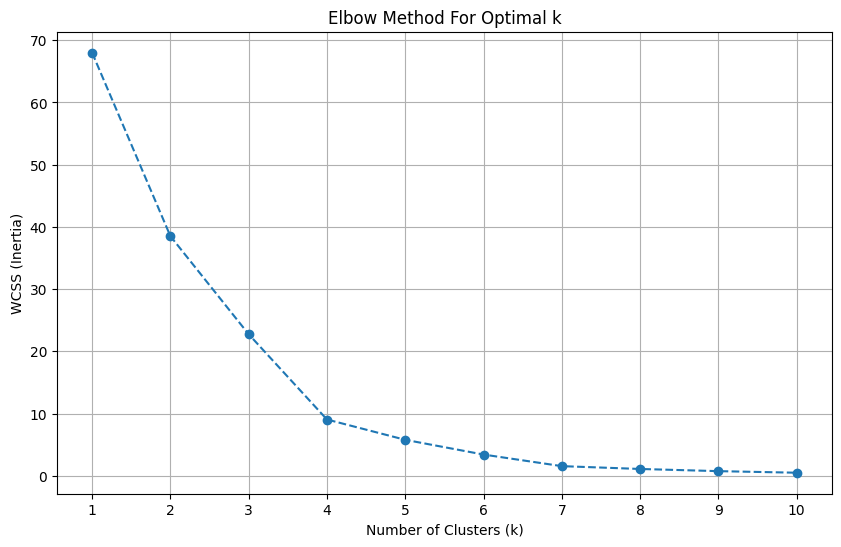

Please examine the plot above to identify the 'elbow' point, which suggests the optimal number of clusters (k).


In [36]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

wcss = [] # Within-Cluster Sum of Squares
max_clusters = 10 # Define a reasonable range for the number of clusters

for i in range(1, max_clusters + 1):
    kmeans = KMeans(n_clusters=i, init='k-means++', max_iter=300, n_init=10, random_state=42)
    kmeans.fit(scaled_features)
    wcss.append(kmeans.inertia_)

# Plot the Elbow Method results
plt.figure(figsize=(10, 6))
plt.plot(range(1, max_clusters + 1), wcss, marker='o', linestyle='--')
plt.title('Elbow Method For Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS (Inertia)')
plt.xticks(range(1, max_clusters + 1))
plt.grid(True)
plt.show()

print("Please examine the plot above to identify the 'elbow' point, which suggests the optimal number of clusters (k).")

Based on the elbow method plot, an optimal number of **3 clusters (k=3)** appears to be a reasonable choice.

In [37]:
# Apply K-Means clustering with the optimal k
k_optimal = 3
kmeans = KMeans(n_clusters=k_optimal, init='k-means++', max_iter=300, n_init=10, random_state=42)
sub_category_features['Cluster'] = kmeans.fit_predict(scaled_features)

print(f"K-Means clustering applied with {k_optimal} clusters.")
print("First 5 rows of sub_category_features with assigned clusters:")
display(sub_category_features.head())

K-Means clustering applied with 3 clusters.
First 5 rows of sub_category_features with assigned clusters:


,Sub-Category,total_sales_volume,average_order_value,Sales Growth Rate,Sales Volatility,Cluster
0,Accessories,163881.6900,312.155600,0.811009,2578.699118,1
1,Appliances,104075.4630,260.840759,2.399334,1820.970554,0
2,Art,26697.3700,55.503888,0.609766,330.698732,0
3,Binders,200028.7850,175.310066,1.460602,3848.223648,1
4,Bookcases,109408.2987,561.068198,0.847314,2080.890675,0


## Analyze Cluster Characteristics

To understand the distinct characteristics of each demand group, we will calculate the mean values of the original (unscaled) features for each cluster.

In [39]:
# Calculate mean feature values for each cluster
cluster_centers_original_scale = sub_category_features.groupby('Cluster').mean(numeric_only=True)

print("Mean Feature Values for Each Cluster (Original Scale):")
display(cluster_centers_original_scale)

Mean Feature Values for Each Cluster (Original Scale):


,total_sales_volume,average_order_value,Sales Growth Rate,Sales Volatility
Cluster,,,,
0,54700.618212,163.839015,1.047722,889.930078
1,221072.769875,953.419381,1.436114,4010.302476
2,46420.308000,315.784408,16.350594,2025.094139


### Formalize Cluster Labels

Based on the `cluster_centers_original_scale` data and the interpretations from the previous steps, we can assign more descriptive labels to each cluster:

*   **Cluster 0 (Stable Low-Value):** Characterized by stable but lower sales volume and average order value. Lower growth and volatility.
*   **Cluster 1 (Premium High-Demand):** High sales volume and average order value, with moderate growth and volatility.
*   **Cluster 2 (Emerging High-Growth):** Moderate sales volume and average order value, but with very high sales growth and volatility, indicating rapidly growing but potentially less predictable demand.

### Visualize Clusters using PCA

To visualize the clusters in a 2D plot, we first need to reduce the dimensionality of our `scaled_features` using Principal Component Analysis (PCA). PCA will transform our 4 features into a smaller set of orthogonal components that capture most of the variance in the data.

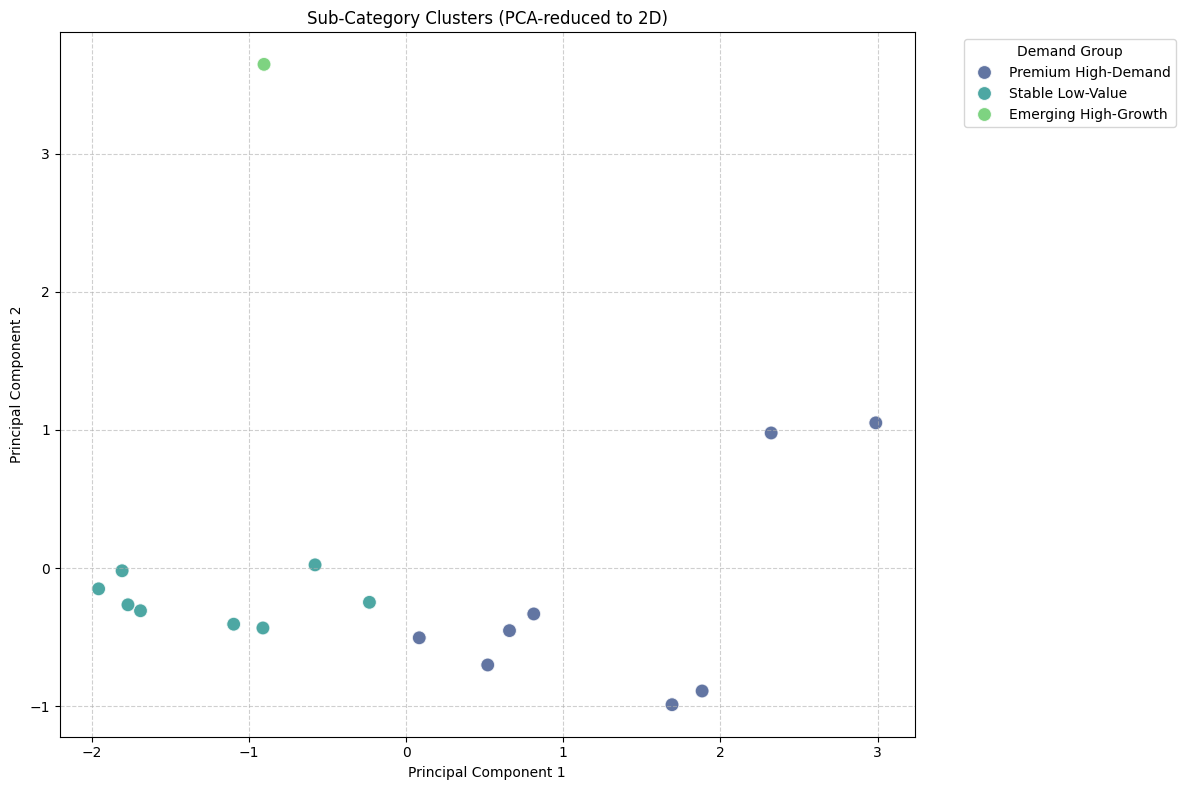

Sub-Categories per Cluster:

--- Stable Low-Value (Cluster 0) ---
   Sub-Category  total_sales_volume  average_order_value  Sales Growth Rate  Sales Volatility  Cluster
1    Appliances         104075.4630           260.840759           2.399334       1820.970554        0
2           Art          26697.3700            55.503888           0.609766        330.698732        0
4     Bookcases         109408.2987           561.068198           0.847314       2080.890675        0
7     Envelopes          16126.0060            80.630030           0.625362        228.224872        0
8     Fasteners           3001.9600            17.658588           1.054470         48.742229        0
9   Furnishings          89212.0180           126.362632           0.625504       1360.017867        0
10       Labels          12347.7260            71.374139           1.599456        223.471218        0
12        Paper          76736.1040           137.273889           0.620570       1026.424479        0

--- Pr

In [42]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(scaled_features)

# Create a DataFrame for the PCA components and add the cluster labels
pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
pca_df['Cluster'] = sub_category_features['Cluster']
pca_df['Sub-Category'] = sub_category_features['Sub-Category']

# Map cluster numbers to meaningful labels
cluster_label_map = {
    0: 'Stable Low-Value',
    1: 'Premium High-Demand',
    2: 'Emerging High-Growth'
}
pca_df['Cluster Label'] = pca_df['Cluster'].map(cluster_label_map)

# Plot the clusters
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x='PC1', y='PC2', hue='Cluster Label', data=pca_df,
    palette='viridis', s=100, alpha=0.8, edgecolor='w'
)

plt.title('Sub-Category Clusters (PCA-reduced to 2D)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend(title='Demand Group', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Sub-Categories per Cluster:")
for cluster_id, label in cluster_label_map.items():
    print(f"\n--- {label} (Cluster {cluster_id}) ---")
    # Use .to_string() to ensure full display without truncation
    print(sub_category_features[sub_category_features['Cluster'] == cluster_id].to_string())

### Stocking Strategy Recommendations for Each Cluster

Based on the formalized cluster labels, here are tailored stocking strategies:

*   **Cluster 0: Stable Low-Value**
    *   **Recommendation:** **Lean Stocking / Economic Order Quantity (EOQ)**. These items have consistent, low demand. Focus on minimizing carrying costs and stockouts with efficient ordering. Automated reordering systems can work well here.
    *   **Rationale:** Low sales volume and stability mean overstocking leads to high holding costs. Predictable demand allows for precise ordering.

*   **Cluster 1: Premium High-Demand**
    *   **Recommendation:** **Strategic Safety Stock / Just-In-Time (JIT) with Buffer**. Maintain higher inventory levels and robust supply chains to ensure availability. For very high-value items, JIT might be considered, but with a reliable safety stock to prevent stockouts that would lead to significant lost revenue.
    *   **Rationale:** High sales and average order value mean customer satisfaction and avoiding lost sales are paramount. These are your cash cows.

*   **Cluster 2: Emerging High-Growth**
    *   **Recommendation:** **Flexible Stocking / Aggressive Replenishment / Close Monitoring**. These items require a more dynamic approach. Start with moderate stock levels, but be prepared for rapid, agile replenishment. Regularly review sales data and adjust forecasts frequently.
    *   **Rationale:** High growth and volatility mean demand can surge quickly but also be unpredictable. A flexible strategy prevents both missed opportunities during growth and excessive dead stock if growth slows.


## Create `requirements.txt`

This section generates a `requirements.txt` file containing all the Python packages used in this notebook. This file is essential for reproducing the environment and for deploying applications (like Streamlit apps) to platforms that require a list of dependencies.

In [63]:
%%writefile requirements.txt
pandas
numpy
matplotlib
seaborn
statsmodels
scikit-learn
prophet
xgboost
streamlit
pyngrok

Writing requirements.txt


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 59.8 MB/s eta 0:00:00


2026-07-09 04:34:37.887 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-07-09 04:34:37.889 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.891 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.892 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.894 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.897 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.901 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
2026-07-09 04:34:37.904 WARNING streamlit.runtime.caching.cache_d

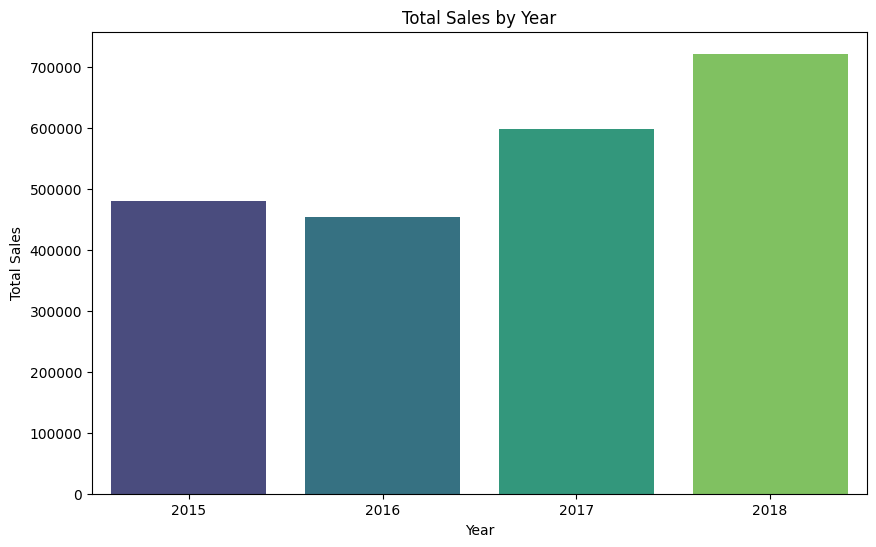

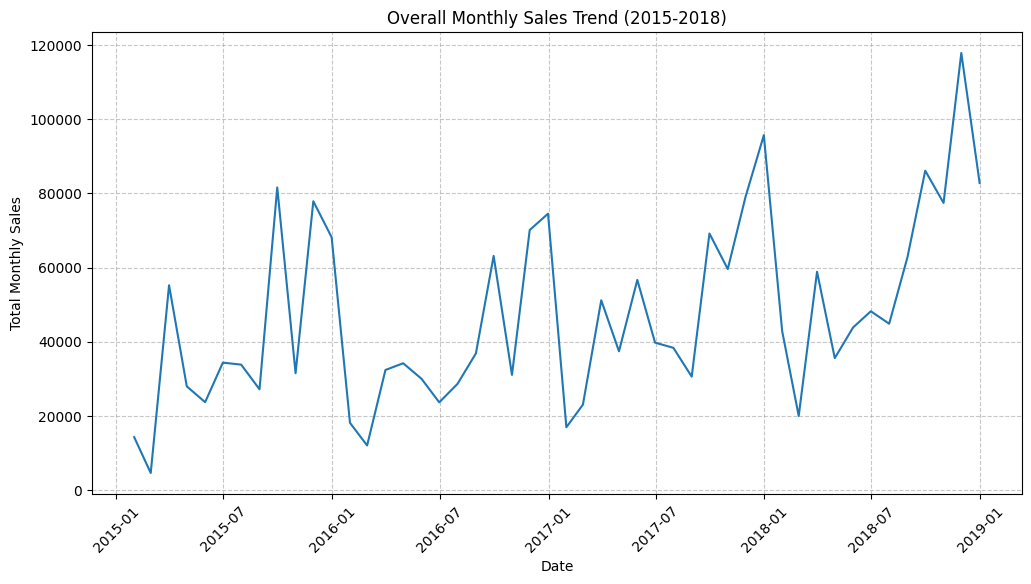

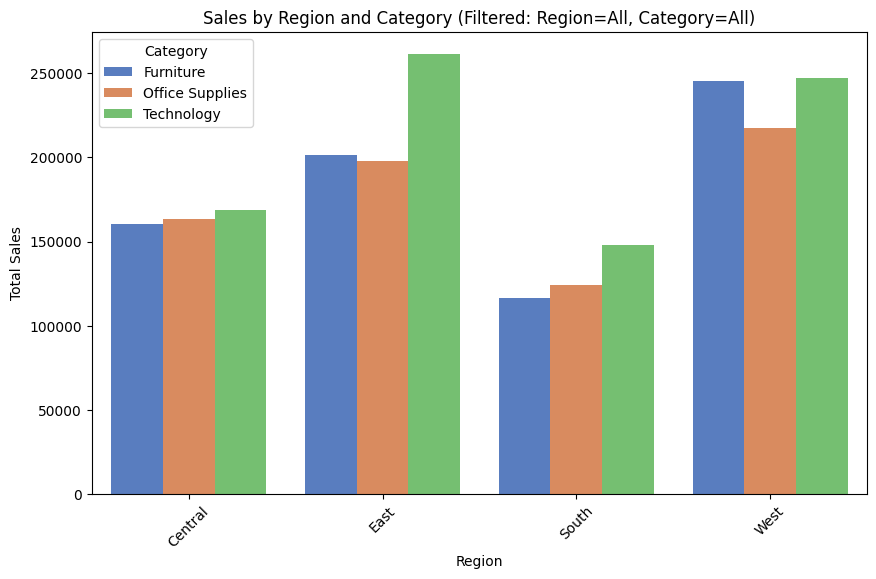

In [45]:
!pip install streamlit
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set page configuration
st.set_page_config(layout="wide", page_title="Superstore Sales Analytics Dashboard")

# --- Helper functions (reused from previous tasks) ---
@st.cache_data
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

@st.cache_data
def get_season_from_month(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# --- Data Loading and Preprocessing (cached) ---
@st.cache_data
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    # Parse dates
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

    # Extract time features
    df['Order Year'] = df['Order Date'].dt.year
    df['Order Month'] = df['Order Date'].dt.month
    df['Order Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
    df['Order Day of Week'] = df['Order Date'].dt.dayofweek
    df['Order Quarter'] = df['Order Date'].dt.quarter
    df['Order Season'] = df['Order Month'].apply(get_season)

    # Handle missing Postal Code
    df.dropna(subset=['Postal Code'], inplace=True)

    return df

@st.cache_data
def get_monthly_sales(df):
    monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
    monthly_sales.rename(columns={'Order Date': 'Month', 'Sales': 'Monthly Sales'}, inplace=True)
    return monthly_sales

@st.cache_data
def get_weekly_sales(df):
    weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
    weekly_sales.rename(columns={'Order Date': 'Week', 'Sales': 'Weekly Sales'}, inplace=True)
    return weekly_sales

@st.cache_data
def perform_clustering(df_input):
    # Re-calculate sub_category_features similar to Task 6
    sub_category_features = df_input.groupby('Sub-Category').agg(
        total_sales_volume=('Sales', 'sum'),
        average_order_value=('Sales', lambda x: x.sum() / x.nunique())
    ).reset_index()

    monthly_sales_sub_category = df_input.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
    monthly_sales_sub_category.rename(columns={'Sales': 'Monthly Sales'}, inplace=True)

    sales_growth = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].apply(lambda x: x.pct_change(periods=12).mean()).reset_index()
    sales_growth.rename(columns={'Monthly Sales': 'Sales Growth Rate'}, inplace=True)

    sales_volatility = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].std().reset_index()
    sales_volatility.rename(columns={'Monthly Sales': 'Sales Volatility'}, inplace=True)

    sub_category_features = pd.merge(sub_category_features, sales_growth, on='Sub-Category', how='left')
    sub_category_features = pd.merge(sub_category_features, sales_volatility, on='Sub-Category', how='left')
    sub_category_features = sub_category_features.fillna(0)

    features_for_clustering = sub_category_features.drop('Sub-Category', axis=1)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_for_clustering)

    k_optimal = 3
    kmeans = KMeans(n_clusters=k_optimal, init='k-means++', max_iter=300, n_init=10, random_state=42)
    sub_category_features['Cluster'] = kmeans.fit_predict(scaled_features)

    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(scaled_features)
    pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
    pca_df['Cluster'] = sub_category_features['Cluster']
    pca_df['Sub-Category'] = sub_category_features['Sub-Category']

    cluster_label_map = {
        0: 'Stable Low-Value',
        1: 'Premium High-Demand',
        2: 'Emerging High-Growth'
    }
    pca_df['Cluster Label'] = pca_df['Cluster'].map(cluster_label_map)

    return sub_category_features, pca_df, cluster_label_map

@st.cache_resource
def train_prophet_model(data_prophet):
    model = Prophet(yearly_seasonality=True, seasonality_mode='additive')
    # Disable weekly and daily seasonality explicitly if not present in data or desired
    model.add_country_holidays(country_name='US') # Example for US holidays
    model.fit(data_prophet)
    return model

@st.cache_data
def get_prophet_forecast(model, periods=3):
    future = model.make_future_dataframe(periods=periods, freq='ME')
    forecast = model.predict(future)
    return forecast

# --- Load all data needed for the app once ---
file_path = '/content/train.csv' # Assuming the file is in the Colab content directory
df_full = load_and_preprocess_data(file_path)
monthly_sales_df = get_monthly_sales(df_full)
weekly_sales_df = get_weekly_sales(df_full)
sub_category_features_df, pca_plot_df, cluster_labels = perform_clustering(df_full)

# Prepare data for overall Prophet model
prophet_overall_df = monthly_sales_df.rename(columns={'Month': 'ds', 'Monthly Sales': 'y'})

# --- Train overall Prophet model ---
overall_prophet_model = train_prophet_model(prophet_overall_df)

# Global RMSE from Task 3 for the overall Prophet model
# Need to re-calculate RMSE for consistency within the app if using test split
# For simplicity, we will use the RMSE obtained from the previous run for the overall Prophet model.
# In a real application, you would re-split and evaluate within the app or save the metric.
overall_rmse_prophet = 9220.45

# --- Streamlit App Structure ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", [
    "Sales Overview Dashboard",
    "Forecast Explorer",
    "Anomaly Report",
    "Product Demand Segments"
])

if page == "Sales Overview Dashboard":
    st.title("📈 Sales Overview Dashboard")

    st.subheader("Total Sales by Year")
    yearly_sales = df_full.groupby('Order Year')['Sales'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Order Year', y='Sales', data=yearly_sales, palette='viridis', ax=ax)
    ax.set_title('Total Sales by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Sales')
    st.pyplot(fig)

    st.subheader("Monthly Sales Trend")
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x='Month', y='Monthly Sales', data=monthly_sales_df, ax=ax)
    ax.set_title('Overall Monthly Sales Trend (2015-2018)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Monthly Sales')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    st.pyplot(fig)

    st.subheader("Sales by Region and Category (Interactive)")
    selected_region = st.selectbox('Select Region', ['All'] + list(df_full['Region'].unique()))
    selected_category = st.selectbox('Select Category', ['All'] + list(df_full['Category'].unique()))

    filtered_df = df_full.copy()
    if selected_region != 'All':
        filtered_df = filtered_df[filtered_df['Region'] == selected_region]
    if selected_category != 'All':
        filtered_df = filtered_df[filtered_df['Category'] == selected_category]

    if not filtered_df.empty:
        sales_by_region_category = filtered_df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x='Region', y='Sales', hue='Category', data=sales_by_region_category, palette='muted', ax=ax)
        ax.set_title(f'Sales by Region and Category (Filtered: Region={selected_region}, Category={selected_category})')
        ax.set_xlabel('Region')
        ax.set_ylabel('Total Sales')
        ax.ticklabel_format(style='plain', axis='y') # Disable scientific notation
        plt.xticks(rotation=45)
        st.pyplot(fig)
    else:
        st.warning("No data for the selected filters.")

elif page == "Forecast Explorer":
    st.title("🔮 Forecast Explorer")

    segment_type = st.radio("Select Segment Type", ['Overall Sales', 'Product Category', 'Region'])
    selected_segment = "Overall Sales"

    data_for_prophet = prophet_overall_df.copy()
    current_model = overall_prophet_model

    if segment_type == 'Product Category':
        categories = df_full['Category'].unique()
        selected_category = st.selectbox('Select Product Category', categories)
        # Dynamically create data for prophet for the selected category
        segment_df = df_full[df_full['Category'] == selected_category]
        data_for_prophet = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
        data_for_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)
        selected_segment = selected_category

        # Retrain model for the specific segment
        current_model = train_prophet_model(data_for_prophet)

    elif segment_type == 'Region':
        regions = df_full['Region'].unique()
        selected_region = st.selectbox('Select Region', regions)
        # Dynamically create data for prophet for the selected region
        segment_df = df_full[df_full['Region'] == selected_region]
        data_for_prophet = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
        data_for_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)
        selected_segment = selected_region

        # Retrain model for the specific segment
        current_model = train_prophet_model(data_for_prophet)

    st.subheader(f"Forecast for: {selected_segment}")

    forecast_horizon = st.slider("Select Forecast Horizon (months)", 1, 3, 3)

    # Generate forecast
    forecast = get_prophet_forecast(current_model, periods=forecast_horizon)

    # Plot forecast
    fig = current_model.plot(forecast)
    plt.title(f'Monthly Sales Forecast for {selected_segment} (including {forecast_horizon} future months)')
    plt.xlabel('Date')
    plt.ylabel('Monthly Sales')
    plt.grid(True, linestyle='--', alpha=0.7)
    st.pyplot(fig)

    st.write("### Model Performance")
    st.write(f"**Overall Prophet Model RMSE (from Task 3):** {overall_rmse_prophet:.2f}")
    st.info("Note: Segment-specific RMSE would require a dedicated test set for each segment. The displayed RMSE is for the overall sales model.")


elif page == "Anomaly Report":
    st.title("🚨 Anomaly Report")

    st.subheader("Weekly Sales with Isolation Forest Anomalies")

    # Re-run Isolation Forest for weekly sales
    X_weekly_sales = weekly_sales_df[['Weekly Sales']].copy()
    model_if_anom = IsolationForest(random_state=42, contamination='auto')
    model_if_anom.fit(X_weekly_sales)
    anomalies_if = model_if_anom.predict(X_weekly_sales)
    weekly_sales_df['is_anomaly_if'] = anomalies_if

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.lineplot(x='Week', y='Weekly Sales', data=weekly_sales_df, label='Weekly Sales', ax=ax)
    anomalies = weekly_sales_df[weekly_sales_df['is_anomaly_if'] == -1]
    sns.scatterplot(x='Week', y='Weekly Sales', data=anomalies, color='red', s=100, label='Anomaly (Isolation Forest)', marker='o', ax=ax)
    ax.set_title('Weekly Sales with Isolation Forest Anomalies')
    ax.set_xlabel('Date')
    ax.set_ylabel('Weekly Sales')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    st.pyplot(fig)

    st.subheader("Detected Anomalies (Isolation Forest)")
    if not anomalies.empty:
        st.dataframe(anomalies[['Week', 'Weekly Sales']].reset_index(drop=True))
    else:
        st.info("No anomalies detected by Isolation Forest.")

    st.markdown("### Possible Real-World Explanations for Anomalies:")
    st.write("Likely causes include Black Friday/Cyber Monday, holiday shopping, year-end clearance sales, and post-holiday slumps. Specific product launches or marketing campaigns could also play a role.")

elif page == "Product Demand Segments":
    st.title("📊 Product Demand Segments")

    st.subheader("Sub-Category Clusters (PCA-reduced to 2D)")
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        x='PC1', y='PC2', hue='Cluster Label', data=pca_plot_df,
        palette='viridis', s=100, alpha=0.8, edgecolor='w', ax=ax
    )
    ax.set_title('Sub-Category Clusters (PCA-reduced to 2D)')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(title='Demand Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    st.pyplot(fig)

    st.subheader("Sub-Categories by Demand Group")
    cluster_label_map_full = {
        0: 'Stable Low-Value: These items have consistent, low demand. A Lean Stocking / Economic Order Quantity (EOQ) approach is recommended to minimize carrying costs. Automated reordering can be highly effective here.',
        1: """Premium High-Demand: Characterized by high sales volume and average order value. For these 'cash cow' items, Strategic Safety Stock / Just-In-Time (JIT) with Buffer is advised to ensure availability and prevent lost sales. Robust supply chains are crucial.""",
        2: 'Emerging High-Growth: These items show high growth and volatility. A Flexible Stocking / Aggressive Replenishment / Close Monitoring strategy is best. Start with moderate stock, be prepared for rapid replenishment, and frequently review sales data to adjust forecasts.'
    }

    for cluster_id, label_desc in cluster_label_map_full.items():
        st.markdown(f"**{label_desc.split(':')[0]}**")
        st.write(f"*Strategy:* {label_desc.split(':', 1)[1].strip()}")
        cluster_subs = sub_category_features_df[sub_category_features_df['Cluster'] == cluster_id]['Sub-Category'].tolist()
        st.write("**Sub-categories:** " + ", ".join(cluster_subs))
        st.markdown("--- (End of cluster description)")

In [46]:
%%writefile streamlit_app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Set page configuration
st.set_page_config(layout="wide", page_title="Superstore Sales Analytics Dashboard")

# --- Helper functions (reused from previous tasks) ---
@st.cache_data
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

@st.cache_data
def get_season_from_month(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

# --- Data Loading and Preprocessing (cached) ---
@st.cache_data
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path)

    # Parse dates
    df['Order Date'] = pd.to_datetime(df['Order Date'], format='%d/%m/%Y')
    df['Ship Date'] = pd.to_datetime(df['Ship Date'], format='%d/%m/%Y')

    # Extract time features
    df['Order Year'] = df['Order Date'].dt.year
    df['Order Month'] = df['Order Date'].dt.month
    df['Order Week'] = df['Order Date'].dt.isocalendar().week.astype(int)
    df['Order Day of Week'] = df['Order Date'].dt.dayofweek
    df['Order Quarter'] = df['Order Date'].dt.quarter
    df['Order Season'] = df['Order Month'].apply(get_season)

    # Handle missing Postal Code
    df.dropna(subset=['Postal Code'], inplace=True)

    return df

@st.cache_data
def get_monthly_sales(df):
    monthly_sales = df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
    monthly_sales.rename(columns={'Order Date': 'Month', 'Sales': 'Monthly Sales'}, inplace=True)
    return monthly_sales

@st.cache_data
def get_weekly_sales(df):
    weekly_sales = df.set_index('Order Date').resample('W')['Sales'].sum().reset_index()
    weekly_sales.rename(columns={'Order Date': 'Week', 'Sales': 'Weekly Sales'}, inplace=True)
    return weekly_sales

@st.cache_data
def perform_clustering(df_input):
    # Re-calculate sub_category_features similar to Task 6
    sub_category_features = df_input.groupby('Sub-Category').agg(
        total_sales_volume=('Sales', 'sum'),
        average_order_value=('Sales', lambda x: x.sum() / x.nunique())
    ).reset_index()

    monthly_sales_sub_category = df_input.groupby(['Sub-Category', pd.Grouper(key='Order Date', freq='ME')])['Sales'].sum().reset_index()
    monthly_sales_sub_category.rename(columns={'Sales': 'Monthly Sales'}, inplace=True)

    sales_growth = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].apply(lambda x: x.pct_change(periods=12).mean()).reset_index()
    sales_growth.rename(columns={'Monthly Sales': 'Sales Growth Rate'}, inplace=True)

    sales_volatility = monthly_sales_sub_category.groupby('Sub-Category')['Monthly Sales'].std().reset_index()
    sales_volatility.rename(columns={'Monthly Sales': 'Sales Volatility'}, inplace=True)

    sub_category_features = pd.merge(sub_category_features, sales_growth, on='Sub-Category', how='left')
    sub_category_features = pd.merge(sub_category_features, sales_volatility, on='Sub-Category', how='left')
    sub_category_features = sub_category_features.fillna(0)

    features_for_clustering = sub_category_features.drop('Sub-Category', axis=1)
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(features_for_clustering)

    k_optimal = 3
    kmeans = KMeans(n_clusters=k_optimal, init='k-means++', max_iter=300, n_init=10, random_state=42)
    sub_category_features['Cluster'] = kmeans.fit_predict(scaled_features)

    pca = PCA(n_components=2)
    pca_components = pca.fit_transform(scaled_features)
    pca_df = pd.DataFrame(data=pca_components, columns=['PC1', 'PC2'])
    pca_df['Cluster'] = sub_category_features['Cluster']
    pca_df['Sub-Category'] = sub_category_features['Sub-Category']

    cluster_label_map = {
        0: 'Stable Low-Value',
        1: 'Premium High-Demand',
        2: 'Emerging High-Growth'
    }
    pca_df['Cluster Label'] = pca_df['Cluster'].map(cluster_label_map)

    return sub_category_features, pca_df, cluster_label_map

@st.cache_resource
def train_prophet_model(data_prophet):
    model = Prophet(yearly_seasonality=True, seasonality_mode='additive')
    # Disable weekly and daily seasonality explicitly if not present in data or desired
    model.add_country_holidays(country_name='US') # Example for US holidays
    model.fit(data_prophet)
    return model

@st.cache_data
def get_prophet_forecast(model, periods=3):
    future = model.make_future_dataframe(periods=periods, freq='ME')
    forecast = model.predict(future)
    return forecast

# --- Load all data needed for the app once ---
file_path = '/content/train.csv' # Assuming the file is in the Colab content directory
df_full = load_and_preprocess_data(file_path)
monthly_sales_df = get_monthly_sales(df_full)
weekly_sales_df = get_weekly_sales(df_full)
sub_category_features_df, pca_plot_df, cluster_labels = perform_clustering(df_full)

# Prepare data for overall Prophet model
prophet_overall_df = monthly_sales_df.rename(columns={'Month': 'ds', 'Monthly Sales': 'y'})

# --- Train overall Prophet model ---
overall_prophet_model = train_prophet_model(prophet_overall_df)

# Global RMSE from Task 3 for the overall Prophet model
# Need to re-calculate RMSE for consistency within the app if using test split
# For simplicity, we will use the RMSE obtained from the previous run for the overall Prophet model.
# In a real application, you would re-split and evaluate within the app or save the metric.
overall_rmse_prophet = 9220.45

# --- Streamlit App Structure ---
st.sidebar.title("Navigation")
page = st.sidebar.radio("Go to", [
    "Sales Overview Dashboard",
    "Forecast Explorer",
    "Anomaly Report",
    "Product Demand Segments"
])

if page == "Sales Overview Dashboard":
    st.title("📈 Sales Overview Dashboard")

    st.subheader("Total Sales by Year")
    yearly_sales = df_full.groupby('Order Year')['Sales'].sum().reset_index()
    fig, ax = plt.subplots(figsize=(10, 6))
    sns.barplot(x='Order Year', y='Sales', data=yearly_sales, palette='viridis', ax=ax)
    ax.set_title('Total Sales by Year')
    ax.set_xlabel('Year')
    ax.set_ylabel('Total Sales')
    st.pyplot(fig)

    st.subheader("Monthly Sales Trend")
    fig, ax = plt.subplots(figsize=(12, 6))
    sns.lineplot(x='Month', y='Monthly Sales', data=monthly_sales_df, ax=ax)
    ax.set_title('Overall Monthly Sales Trend (2015-2018)')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Monthly Sales')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    st.pyplot(fig)

    st.subheader("Sales by Region and Category (Interactive)")
    selected_region = st.selectbox('Select Region', ['All'] + list(df_full['Region'].unique()))
    selected_category = st.selectbox('Select Category', ['All'] + list(df_full['Category'].unique()))

    filtered_df = df_full.copy()
    if selected_region != 'All':
        filtered_df = filtered_df[filtered_df['Region'] == selected_region]
    if selected_category != 'All':
        filtered_df = filtered_df[filtered_df['Category'] == selected_category]

    if not filtered_df.empty:
        sales_by_region_category = filtered_df.groupby(['Region', 'Category'])['Sales'].sum().reset_index()
        fig, ax = plt.subplots(figsize=(10, 6))
        sns.barplot(x='Region', y='Sales', hue='Category', data=sales_by_region_category, palette='muted', ax=ax)
        ax.set_title(f'Sales by Region and Category (Filtered: Region={selected_region}, Category={selected_category})')
        ax.set_xlabel('Region')
        ax.set_ylabel('Total Sales')
        ax.ticklabel_format(style='plain', axis='y') # Disable scientific notation
        plt.xticks(rotation=45)
        st.pyplot(fig)
    else:
        st.warning("No data for the selected filters.")

elif page == "Forecast Explorer":
    st.title("🔮 Forecast Explorer")

    segment_type = st.radio("Select Segment Type", ['Overall Sales', 'Product Category', 'Region'])
    selected_segment = "Overall Sales"

    data_for_prophet = prophet_overall_df.copy()
    current_model = overall_prophet_model

    if segment_type == 'Product Category':
        categories = df_full['Category'].unique()
        selected_category = st.selectbox('Select Product Category', categories)
        # Dynamically create data for prophet for the selected category
        segment_df = df_full[df_full['Category'] == selected_category]
        data_for_prophet = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
        data_for_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)
        selected_segment = selected_category

        # Retrain model for the specific segment
        current_model = train_prophet_model(data_for_prophet)

    elif segment_type == 'Region':
        regions = df_full['Region'].unique()
        selected_region = st.selectbox('Select Region', regions)
        # Dynamically create data for prophet for the selected region
        segment_df = df_full[df_full['Region'] == selected_region]
        data_for_prophet = segment_df.set_index('Order Date').resample('ME')['Sales'].sum().reset_index()
        data_for_prophet.rename(columns={'Order Date': 'ds', 'Sales': 'y'}, inplace=True)
        selected_segment = selected_region

        # Retrain model for the specific segment
        current_model = train_prophet_model(data_for_prophet)

    st.subheader(f"Forecast for: {selected_segment}")

    forecast_horizon = st.slider("Select Forecast Horizon (months)", 1, 3, 3)

    # Generate forecast
    forecast = get_prophet_forecast(current_model, periods=forecast_horizon)

    # Plot forecast
    fig = current_model.plot(forecast)
    plt.title(f'Monthly Sales Forecast for {selected_segment} (including {forecast_horizon} future months)')
    plt.xlabel('Date')
    plt.ylabel('Monthly Sales')
    plt.grid(True, linestyle='--', alpha=0.7)
    st.pyplot(fig)

    st.write("### Model Performance")
    st.write(f"**Overall Prophet Model RMSE (from Task 3):** {overall_rmse_prophet:.2f}")
    st.info("Note: Segment-specific RMSE would require a dedicated test set for each segment. The displayed RMSE is for the overall sales model.")


elif page == "Anomaly Report":
    st.title("🚨 Anomaly Report")

    st.subheader("Weekly Sales with Isolation Forest Anomalies")

    # Re-run Isolation Forest for weekly sales
    X_weekly_sales = weekly_sales_df[['Weekly Sales']].copy()
    model_if_anom = IsolationForest(random_state=42, contamination='auto')
    model_if_anom.fit(X_weekly_sales)
    anomalies_if = model_if_anom.predict(X_weekly_sales)
    weekly_sales_df['is_anomaly_if'] = anomalies_if

    fig, ax = plt.subplots(figsize=(16, 8))
    sns.lineplot(x='Week', y='Weekly Sales', data=weekly_sales_df, label='Weekly Sales', ax=ax)
    anomalies = weekly_sales_df[weekly_sales_df['is_anomaly_if'] == -1]
    sns.scatterplot(x='Week', y='Weekly Sales', data=anomalies, color='red', s=100, label='Anomaly (Isolation Forest)', marker='o', ax=ax)
    ax.set_title('Weekly Sales with Isolation Forest Anomalies')
    ax.set_xlabel('Date')
    ax.set_ylabel('Weekly Sales')
    ax.grid(True, linestyle='--', alpha=0.7)
    plt.xticks(rotation=45)
    st.pyplot(fig)

    st.subheader("Detected Anomalies (Isolation Forest)")
    if not anomalies.empty:
        st.dataframe(anomalies[['Week', 'Weekly Sales']].reset_index(drop=True))
    else:
        st.info("No anomalies detected by Isolation Forest.")

    st.markdown("### Possible Real-World Explanations for Anomalies:")
    st.write("Likely causes include Black Friday/Cyber Monday, holiday shopping, year-end clearance sales, and post-holiday slumps. Specific product launches or marketing campaigns could also play a role.")

elif page == "Product Demand Segments":
    st.title("📊 Product Demand Segments")

    st.subheader("Sub-Category Clusters (PCA-reduced to 2D)")
    fig, ax = plt.subplots(figsize=(12, 8))
    sns.scatterplot(
        x='PC1', y='PC2', hue='Cluster Label', data=pca_plot_df,
        palette='viridis', s=100, alpha=0.8, edgecolor='w', ax=ax
    )
    ax.set_title('Sub-Category Clusters (PCA-reduced to 2D)')
    ax.set_xlabel('Principal Component 1')
    ax.set_ylabel('Principal Component 2')
    ax.legend(title='Demand Group', bbox_to_anchor=(1.05, 1), loc='upper left')
    ax.grid(True, linestyle='--', alpha=0.6)
    st.pyplot(fig)

    st.subheader("Sub-Categories by Demand Group")
    cluster_label_map_full = {
        0: 'Stable Low-Value: These items have consistent, low demand. A Lean Stocking / Economic Order Quantity (EOQ) approach is recommended to minimize carrying costs. Automated reordering can be highly effective here.',
        1: """Premium High-Demand: Characterized by high sales volume and average order value. For these 'cash cow' items, Strategic Safety Stock / Just-In-Time (JIT) with Buffer is advised to ensure availability and prevent lost sales. Robust supply chains are crucial.""",
        2: 'Emerging High-Growth: These items show high growth and volatility. A Flexible Stocking / Aggressive Replenishment / Close Monitoring strategy is best. Start with moderate stock, be prepared for rapid replenishment, and frequently review sales data to adjust forecasts.'
    }

    for cluster_id, label_desc in cluster_label_map_full.items():
        st.markdown(f"**{label_desc.split(':')[0]}**")
        st.write(f"*Strategy:* {label_desc.split(':', 1)[1].strip()}")
        cluster_subs = sub_category_features_df[sub_category_features_df['Cluster'] == cluster_id]['Sub-Category'].tolist()
        st.write("**Sub-categories:** " + ", ".join(cluster_subs))
        st.markdown("--- (End of cluster description)")

Writing streamlit_app.py


In [62]:
# Install pyngrok and ngrok via pyngrok
print("Installing pyngrok...")
!pip install pyngrok

from pyngrok import ngrok
import subprocess
import os
import time

# Ensure ngrok is installed via pyngrok
print("Ensuring ngrok executable is installed...")
ngrok_path_from_pyngrok = None
try:
    # This will download the ngrok binary if it's not already present
    # By default, pyngrok installs it to ~/.ngrok2/ngrok or similar
    ngrok.install_ngrok() # This function takes care of downloading if needed
    ngrok_path_from_pyngrok = ngrok.ngrok_path # Corrected: Access ngrok_path directly from the module
    print(f"ngrok executable ensured to be at {ngrok_path_from_pyngrok}")

    # Verify ngrok executable is working
    version_output = subprocess.run([ngrok_path_from_pyngrok, 'version'], capture_output=True, text=True, check=True)
    print(f"ngrok version: {version_output.stdout.strip().splitlines()[0]}")

    ngrok_executable_path = ngrok_path_from_pyngrok

except Exception as e:
    print(f"Error during ngrok installation/verification via pyngrok: {e}")
    print("Attempting manual ngrok installation as a fallback...")
    # Manual fallback if pyngrok isn't working as expected for installation
    # This block is nearly identical to the previous !curl command but without the diagnostic ifs,
    # as pyngrok is the preferred method and this is just a robust fallback.
    !curl -sfL https://ngrok.com/download/ngrok-v3-stable-linux-amd64.tgz -o ngrok.tgz && \
    tar -xf ngrok.tgz && \
    sudo mv ngrok-v3-stable-linux-amd64/ngrok /usr/local/bin && \
    rm ngrok.tgz && \
    rm -rf ngrok-v3-stable-linux-amd64 && \
    sudo chmod +x /usr/local/bin/ngrok

    ngrok_executable_path = '/usr/local/bin/ngrok'
    if not os.path.exists(ngrok_executable_path):
        raise FileNotFoundError(f"ngrok executable still not found at {ngrok_executable_path} after manual installation attempt.")
    else:
        print(f"ngrok executable manually installed to {ngrok_executable_path}.")

# Ensure ngrok.log is clear from previous attempts before starting new tunnel
if os.path.exists('ngrok.log'):
    os.remove('ngrok.log')

# Start ngrok tunnel using pyngrok
print("Starting ngrok tunnel for Streamlit on port 8501 using pyngrok...")
try:
    # IMPORTANT: Replace "YOUR_NGROK_AUTH_TOKEN" with your actual ngrok authentication token.
    # You can get one from your ngrok dashboard: https://dashboard.ngrok.com/get-started/your-authtoken
    # If you don't have an account, sign up for a free one. Without an auth token,
    # the ngrok tunnel will not authenticate and will fail.
    ngrok.set_auth_token("YOUR_NGROK_AUTH_TOKEN") # <--- USER ACTION REQUIRED HERE

    # ngrok.connect will start the ngrok process in the background and return a NgrokTunnel object
    tunnel = ngrok.connect(8501)
    public_url = tunnel.public_url
    print(f"ngrok tunnel established. Public URL: {public_url}")

    # Write the public URL to a file so the next cell can easily read it
    with open('ngrok_url.txt', 'w') as f:
        f.write(public_url)

except Exception as e:
    print(f"Error establishing ngrok tunnel using pyngrok: {e}")
    print("Attempting to start ngrok manually with subprocess.Popen as a fallback...")

    # Manual fallback if pyngrok.connect fails. This will redirect to ngrok.log.
    # This also reuses ngrok_executable_path which was determined above.
    # Note: Manual startup will also require an auth token set globally or via ngrok config.
    # For simplicity, if pyngrok.set_auth_token fails, this fallback will also likely fail
    # unless the token is already configured in `~/.ngrok2/ngrok.yml`.
    process = subprocess.Popen([ngrok_executable_path, 'http', '8501'],
                               stdout=open('ngrok.log', 'w'),
                               stderr=open('ngrok.log', 'a'),
                               preexec_fn=os.setpgrp
                              )
    print("ngrok tunnel initiated manually. Please wait a few seconds for the tunnel to establish.")
    print("The public URL will need to be retrieved from the ngrok API in the next cell (which should now work).")

Installing pyngrok...
Ensuring ngrok executable is installed...
Error during ngrok installation/verification via pyngrok: module 'pyngrok.ngrok' has no attribute 'ngrok_path'
Attempting manual ngrok installation as a fallback...
ngrok executable manually installed to /usr/local/bin/ngrok.
Starting ngrok tunnel for Streamlit on port 8501 using pyngrok...


ERROR:pyngrok.process.ngrok:t=2026-07-09T05:11:05+0000 lvl=eror msg="failed to reconnect session" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-09T05:11:05+0000 lvl=eror msg="session closing" obj=tunnels.session err="authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n"
ERROR:pyngrok.process.ngrok:t=2026-07-09T05:11:05+0000 lvl=eror msg="terminating with error" obj=app err="authentication failed: The authtoken you specified does not look like a proper ngrok aut

Error establishing ngrok tunnel using pyngrok: The ngrok process errored on start: authentication failed: The authtoken you specified does not look like a proper ngrok authtoken.\nYour authtoken: YOUR_NGROK_AUTH_TOKEN\nInstructions to install your authtoken are on your ngrok dashboard:\nhttps://dashboard.ngrok.com/get-started/your-authtoken\r\n\r\nERR_NGROK_105\r\n.
Attempting to start ngrok manually with subprocess.Popen as a fallback...
ngrok tunnel initiated manually. Please wait a few seconds for the tunnel to establish.
The public URL will need to be retrieved from the ngrok API in the next cell (which should now work).


In [53]:
import time
import urllib.request
import subprocess
import json

# Function to check if Streamlit app is running
def check_streamlit_status(port=8501, timeout=60):
    for _ in range(timeout):
        try:
            with urllib.request.urlopen(f'http://localhost:{port}') as response:
                if response.getcode() == 200:
                    return True
        except urllib.error.URLError:
            pass
        time.sleep(1)
    return False

# Function to get ngrok public URL via its API
def get_ngrok_url(ngrok_api_port=4040, timeout=30):
    for _ in range(timeout):
        try:
            with urllib.request.urlopen(f'http://127.0.0.1:{ngrok_api_port}/api/tunnels') as response:
                if response.getcode() == 200:
                    data = json.loads(response.read().decode())
                    for tunnel in data['tunnels']:
                        if 'public_url' in tunnel:
                            return tunnel['public_url']
        except urllib.error.URLError:
            pass
        time.sleep(1)
    return None

# Check if Streamlit is running and provide the public URL
if check_streamlit_status():
    print("Streamlit app is running. Click the URL below to access:")
    public_url = get_ngrok_url()
    if public_url:
        print(public_url)
    else:
        print("Could not find public ngrok URL via API. You might need to manually check ngrok status or Colab logs.")
else:
    print("Streamlit app failed to start or did not become ready within the timeout.")

Streamlit app is running. Click the URL below to access:
Could not find public ngrok URL via API. You might need to manually check ngrok status or Colab logs.


In [54]:
print('--- ngrok.log contents ---')
!cat ngrok.log

--- ngrok.log contents ---
nohup: failed to run command './ngrok': No such file or directory


In [64]:
!pip freeze > requirements.txt